In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
MAIN_FOLDER = "../"

In [2]:
# 1. Load dataset
FILE_NAME = "patient_list_with_ids"

# Read the excel file
df = pd.read_excel("../../"+FILE_NAME+".xlsx")

# Show the head
print(df.tail())

      id         name pell_gregory  pederson winter_angulation  age gender_eng
795  398  398-SAĞ ALT           2A         7      distoangular   33     female
796  399  399-SOL ALT           2A         6          vertical   24     female
797  399  399-SAĞ ALT           2A         6          vertical   24     female
798  400  400-SOL ALT           2B         6        horizontal   23       male
799  400  400-SAĞ ALT           2A         5        horizontal   23       male


In [3]:
# 2. Basic cleaning

# Keep only the columns needed for this analysis
clinical_columns = ["id","name", "pell_gregory", "pederson", "winter_angulation"]

df_clinical = df[clinical_columns].copy()

# Remove leading/trailing spaces from text columns
for col in ["name", "pell_gregory", "winter_angulation"]:
    df_clinical[col] = df_clinical[col].astype(str).str.strip()

# Convert Pell-Gregory classes to uppercase
df_clinical["pell_gregory"] = df_clinical["pell_gregory"].str.upper()

# Convert Winter angulation values to lowercase first, then title case
df_clinical["winter_angulation"] = (
    df_clinical["winter_angulation"]
    .str.strip()
    .str.lower()
    .str.replace("_", " ")
    .str.title()
)

# Convert Pederson score to numeric
df_clinical["pederson"] = pd.to_numeric(df_clinical["pederson"], errors="coerce")
df_clinical.tail()

,id,name,pell_gregory,pederson,winter_angulation
795,398,398-SAĞ ALT,2A,7,Distoangular
796,399,399-SOL ALT,2A,6,Vertical
797,399,399-SAĞ ALT,2A,6,Vertical
798,400,400-SOL ALT,2B,6,Horizontal
799,400,400-SAĞ ALT,2A,5,Horizontal


In [4]:
# 3. Extract patient ID and side from name

# Extract side information from name
def extract_side(name):
    name = str(name).upper().strip()

    if "SOL" in name:
        return "left"
    elif "SAĞ" in name or "SAG" in name:
        return "right"
    else:
        return "unknown"

df_clinical["side"] = df_clinical["name"].apply(extract_side)
df_clinical.tail()

,id,name,pell_gregory,pederson,winter_angulation,side
795,398,398-SAĞ ALT,2A,7,Distoangular,right
796,399,399-SOL ALT,2A,6,Vertical,left
797,399,399-SAĞ ALT,2A,6,Vertical,right
798,400,400-SOL ALT,2B,6,Horizontal,left
799,400,400-SAĞ ALT,2A,5,Horizontal,right


In [5]:
# 4. Create output folders

output_folder = MAIN_FOLDER+"clinical_statistics_outputs"
figures_folder = os.path.join(output_folder, "figures")
tables_folder = os.path.join(output_folder, "tables")

os.makedirs(figures_folder, exist_ok=True)
os.makedirs(tables_folder, exist_ok=True)

In [6]:
# 5. Helper functions

def frequency_table(data, column, order=None):
    """
    Create a frequency and percentage table for a categorical column.
    """
    if order is not None:
        counts = data[column].value_counts(dropna=False).reindex(order, fill_value=0)
    else:
        counts = data[column].value_counts(dropna=False)

    percentages = (counts / counts.sum()) * 100

    table = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })

    return table


def save_frequency_table(data, column, label, order=None):
    """
    Save frequency table as CSV and Excel files.
    """
    table = frequency_table(data, column, order)

    csv_path = os.path.join(tables_folder, f"{column}_frequency_table.csv")
    excel_path = os.path.join(tables_folder, f"{column}_frequency_table.xlsx")

    table.to_csv(csv_path)
    table.to_excel(excel_path)

    print(f"\n{label} Frequency Table")
    print(table)

    return table


def my_autopct(pct):
    """
    Hide very small percentages on pie chart.
    """
    return ("%1.1f%%" % pct) if pct > 1.0 else ""

def chi_square_test(data, col1, col2):
    """
    Perform Chi-square test between two categorical variables.
    """
    table = pd.crosstab(data[col1], data[col2])

    chi2, p_value, dof, expected = chi2_contingency(table)

    result = pd.DataFrame({
        "Chi-square": [chi2],
        "p-value": [p_value],
        "Degrees of freedom": [dof]
    })

    return table, result

In [7]:
# 6. Descriptive overview

print("\nGeneral Information")
print("-------------------")
print("Number of tooth-level records:", len(df_clinical))
print("Number of unique patients:", df_clinical["id"].nunique())
print("Number of left records:", (df_clinical["side"] == "left").sum())
print("Number of right records:", (df_clinical["side"] == "right").sum())
print("Number of unknown side records:", (df_clinical["side"] == "unknown").sum())

print("\nMissing Values")
print("--------------")
print(df_clinical.isnull().sum())


General Information
-------------------
Number of tooth-level records: 800
Number of unique patients: 400
Number of left records: 400
Number of right records: 400
Number of unknown side records: 0

Missing Values
--------------
id                   0
name                 0
pell_gregory         0
pederson             0
winter_angulation    0
side                 0
dtype: int64


In [8]:
# 7. Frequency tables and charts

pell_order = ["1A", "1B", "1C", "2A", "2B", "2C", "3A", "3B", "3C"]
side_order = ["left", "right", "unknown"]

categorical_analysis = {
    "pell_gregory": {
        "label": "Pell-Gregory Class",
        "order": pell_order
    },
    "winter_angulation": {
        "label": "Winter Angulation Type",
        "order": None
    },
    "side": {
        "label": "Side",
        "order": side_order
    }
}

In [9]:
table = save_frequency_table(
        df_clinical,
        "pell_gregory",
        "Pell-Gregory Class",
        pell_order
    )


Pell-Gregory Class Frequency Table
              Count  Percentage (%)
pell_gregory                       
1A               65            8.12
1B               20            2.50
1C                9            1.12
2A              232           29.00
2B              259           32.38
2C               49            6.12
3A               15            1.88
3B               58            7.25
3C               93           11.62


In [10]:
def plot_bar(counts, column, label):
    """
    Create and save a high-quality bar chart
    """

    counts_nonzero = counts[counts > 0]


    # ---------------------------
    # Global style settings for academic appearance
    # ---------------------------
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.dpi": 300,
        "savefig.dpi": 300
    })

    # ---------------------------
    # Figure
    # ---------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    # Use a professional blue palette, avoiding very pale colors
    bar_colors = plt.cm.Blues(np.linspace(0.45, 0.85, len(counts_nonzero)))

    bars = ax.bar(
        counts_nonzero.index.astype(str),
        counts_nonzero.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.8
    )

    # ---------------------------
    # Titles and labels
    # ---------------------------
    ax.set_title(f"Distribution of {label}", pad=12, fontweight="bold")
    ax.set_xlabel(label, labelpad=10)
    ax.set_ylabel("Number of Cases", labelpad=10)

    # ---------------------------
    # Axis formatting
    # ---------------------------
    ax.tick_params(axis="x", rotation=0)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment("center")

    # Remove top and right spines for a cleaner academic look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add light horizontal gridlines
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    # ---------------------------
    # Add values on top of bars
    # ---------------------------
    y_max = counts_nonzero.values.max()
    ax.set_ylim(0, y_max * 1.15)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (y_max * 0.02),
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    # ---------------------------
    # Layout and save
    # ---------------------------
    plt.tight_layout()

    bar_path = os.path.join(figures_folder, f"{column}_bar_chart.png")
    plt.savefig(
        bar_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close()

    print(f"Saved: {bar_path}")

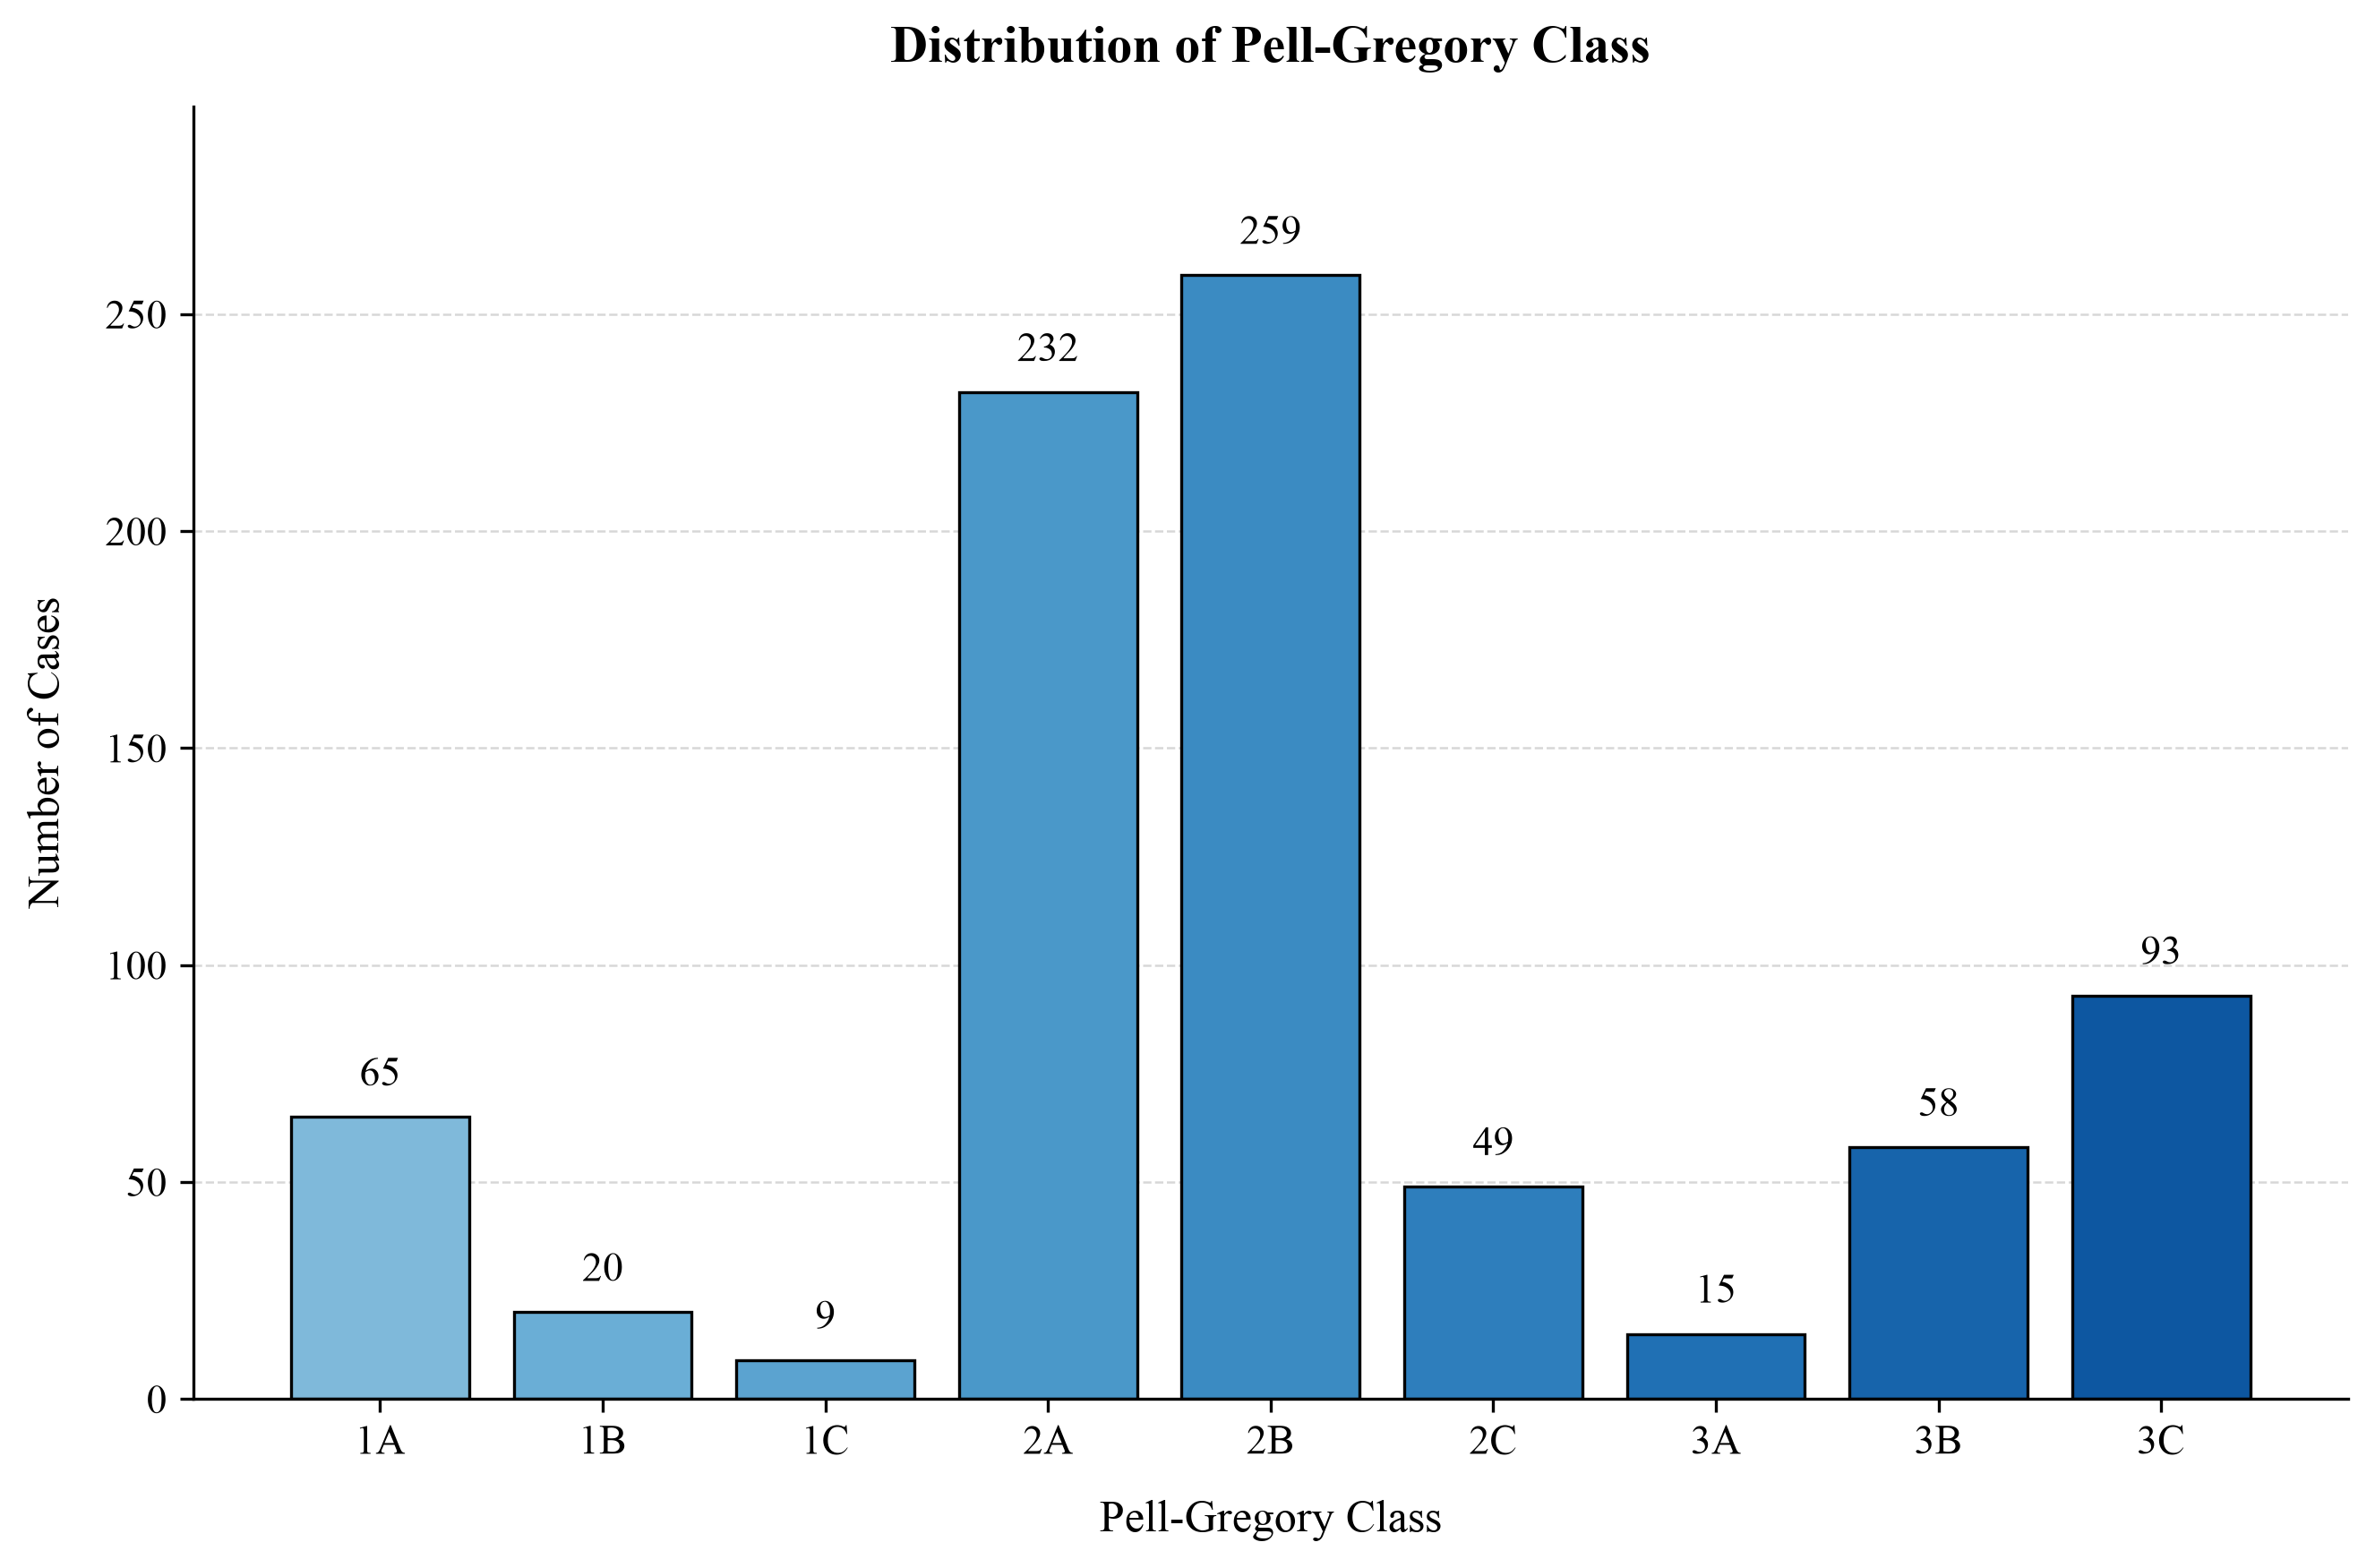

Saved: ../clinical_statistics_outputs/figures/pell_gregory_bar_chart.png


In [11]:
counts = table["Count"]
plot_bar(counts, "pell_gregory", "Pell-Gregory Class")

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_pie(counts, column, label):
    """
    Create and save a high-quality pie chart with outside percentage labels.
    """

    counts_nonzero = counts[counts > 0]

    if counts_nonzero.empty:
        print(f"No data available for {label}. Skipping plot.")
        return

    # ---------------------------
    # Global style settings
    # ---------------------------
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
        "figure.dpi": 300,
        "savefig.dpi": 300
    })

    # ---------------------------
    # Figure
    # ---------------------------
    fig, ax = plt.subplots(figsize=(9, 9))

    pie_colors = plt.cm.Blues(np.linspace(0.45, 0.85, len(counts_nonzero)))

    # ---------------------------
    # Pie chart
    # ---------------------------
    wedges, texts = ax.pie(
        counts_nonzero.values,
        startangle=90,
        colors=pie_colors,
        wedgeprops=dict(
            edgecolor="white",
            linewidth=1.2
        )
    )

    # Equal aspect ratio ensures that pie is drawn as a circle
    ax.axis("equal")

    # ---------------------------
    # Outside percentage labels with connector lines
    # ---------------------------
    total = counts_nonzero.values.sum()

    for i, wedge in enumerate(wedges):
        value = counts_nonzero.values[i]
        percentage = value / total * 100

        # If you want to hide very small percentages, use this
        if percentage < 1:
            continue

        # Angle of the wedge center
        angle = (wedge.theta2 + wedge.theta1) / 2

        # Convert angle to x-y coordinates
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        # Label alignment
        horizontal_alignment = "left" if x >= 0 else "right"

        # Outside label position
        label_x = 1.25 * x
        label_y = 1.25 * y

        ax.annotate(
            f"{percentage:.1f}%",
            xy=(x, y),
            xytext=(label_x, label_y),
            ha=horizontal_alignment,
            va="center",
            fontsize=14,
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.8,
                shrinkA=0,
                shrinkB=0
            )
        )

    # ---------------------------
    # Optional title
    # ---------------------------
    # ax.set_title(
    #     f"Percentage Distribution of {label}",
    #     pad=4,
    #     fontweight="bold"
    # )

    # ---------------------------
    # Legend
    # ---------------------------
    ax.legend(
        wedges,
        counts_nonzero.index.astype(str),
        title=label,
        loc="center left",
        bbox_to_anchor=(1.15, 0.5),
        frameon=False
    )

    # ---------------------------
    # Layout and save
    # ---------------------------
    plt.tight_layout()

    pie_path = os.path.join(figures_folder, f"{column}_pie_chart.png")

    plt.savefig(
        pie_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close()

    print(f"Saved: {pie_path}")

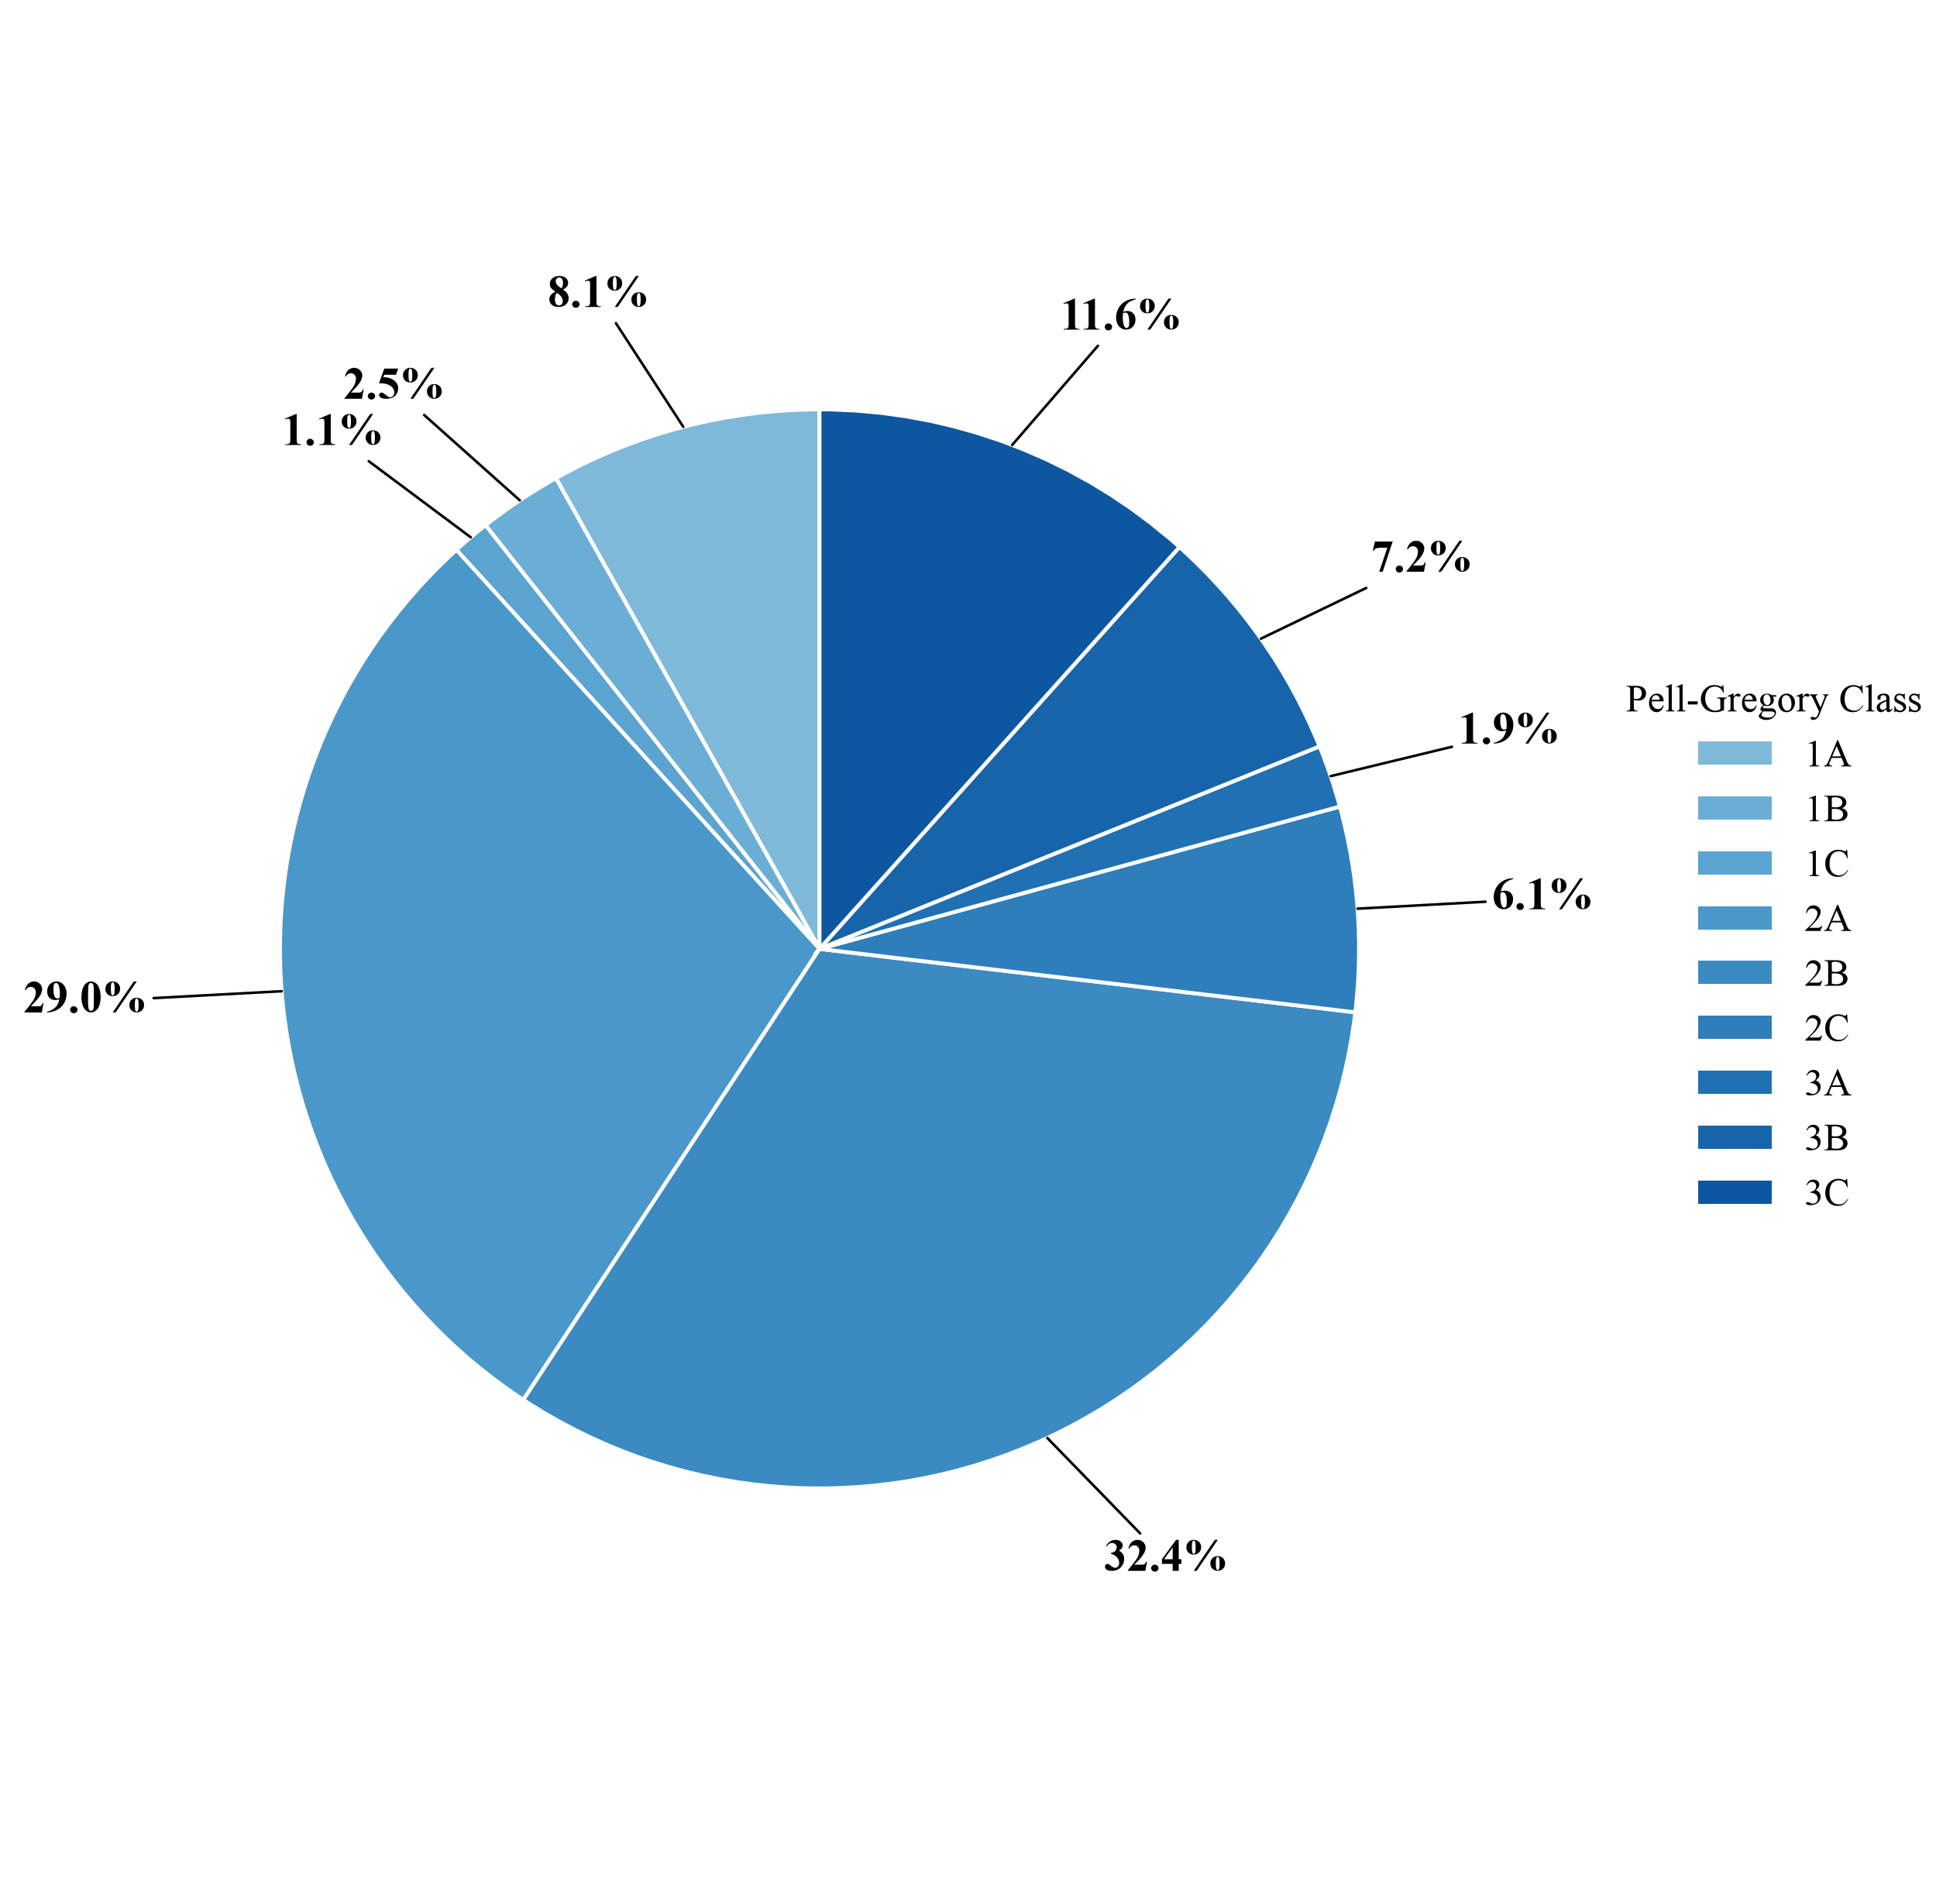

Saved: ../clinical_statistics_outputs/figures/pell_gregory_pie_chart.png


In [13]:
plot_pie(counts, "pell_gregory", "Pell-Gregory Class")

LAB: Pell-Gregory Class
COL:pell_gregory

Pell-Gregory Class Frequency Table
              Count  Percentage (%)
pell_gregory                       
1A               65            8.12
1B               20            2.50
1C                9            1.12
2A              232           29.00
2B              259           32.38
2C               49            6.12
3A               15            1.88
3B               58            7.25
3C               93           11.62


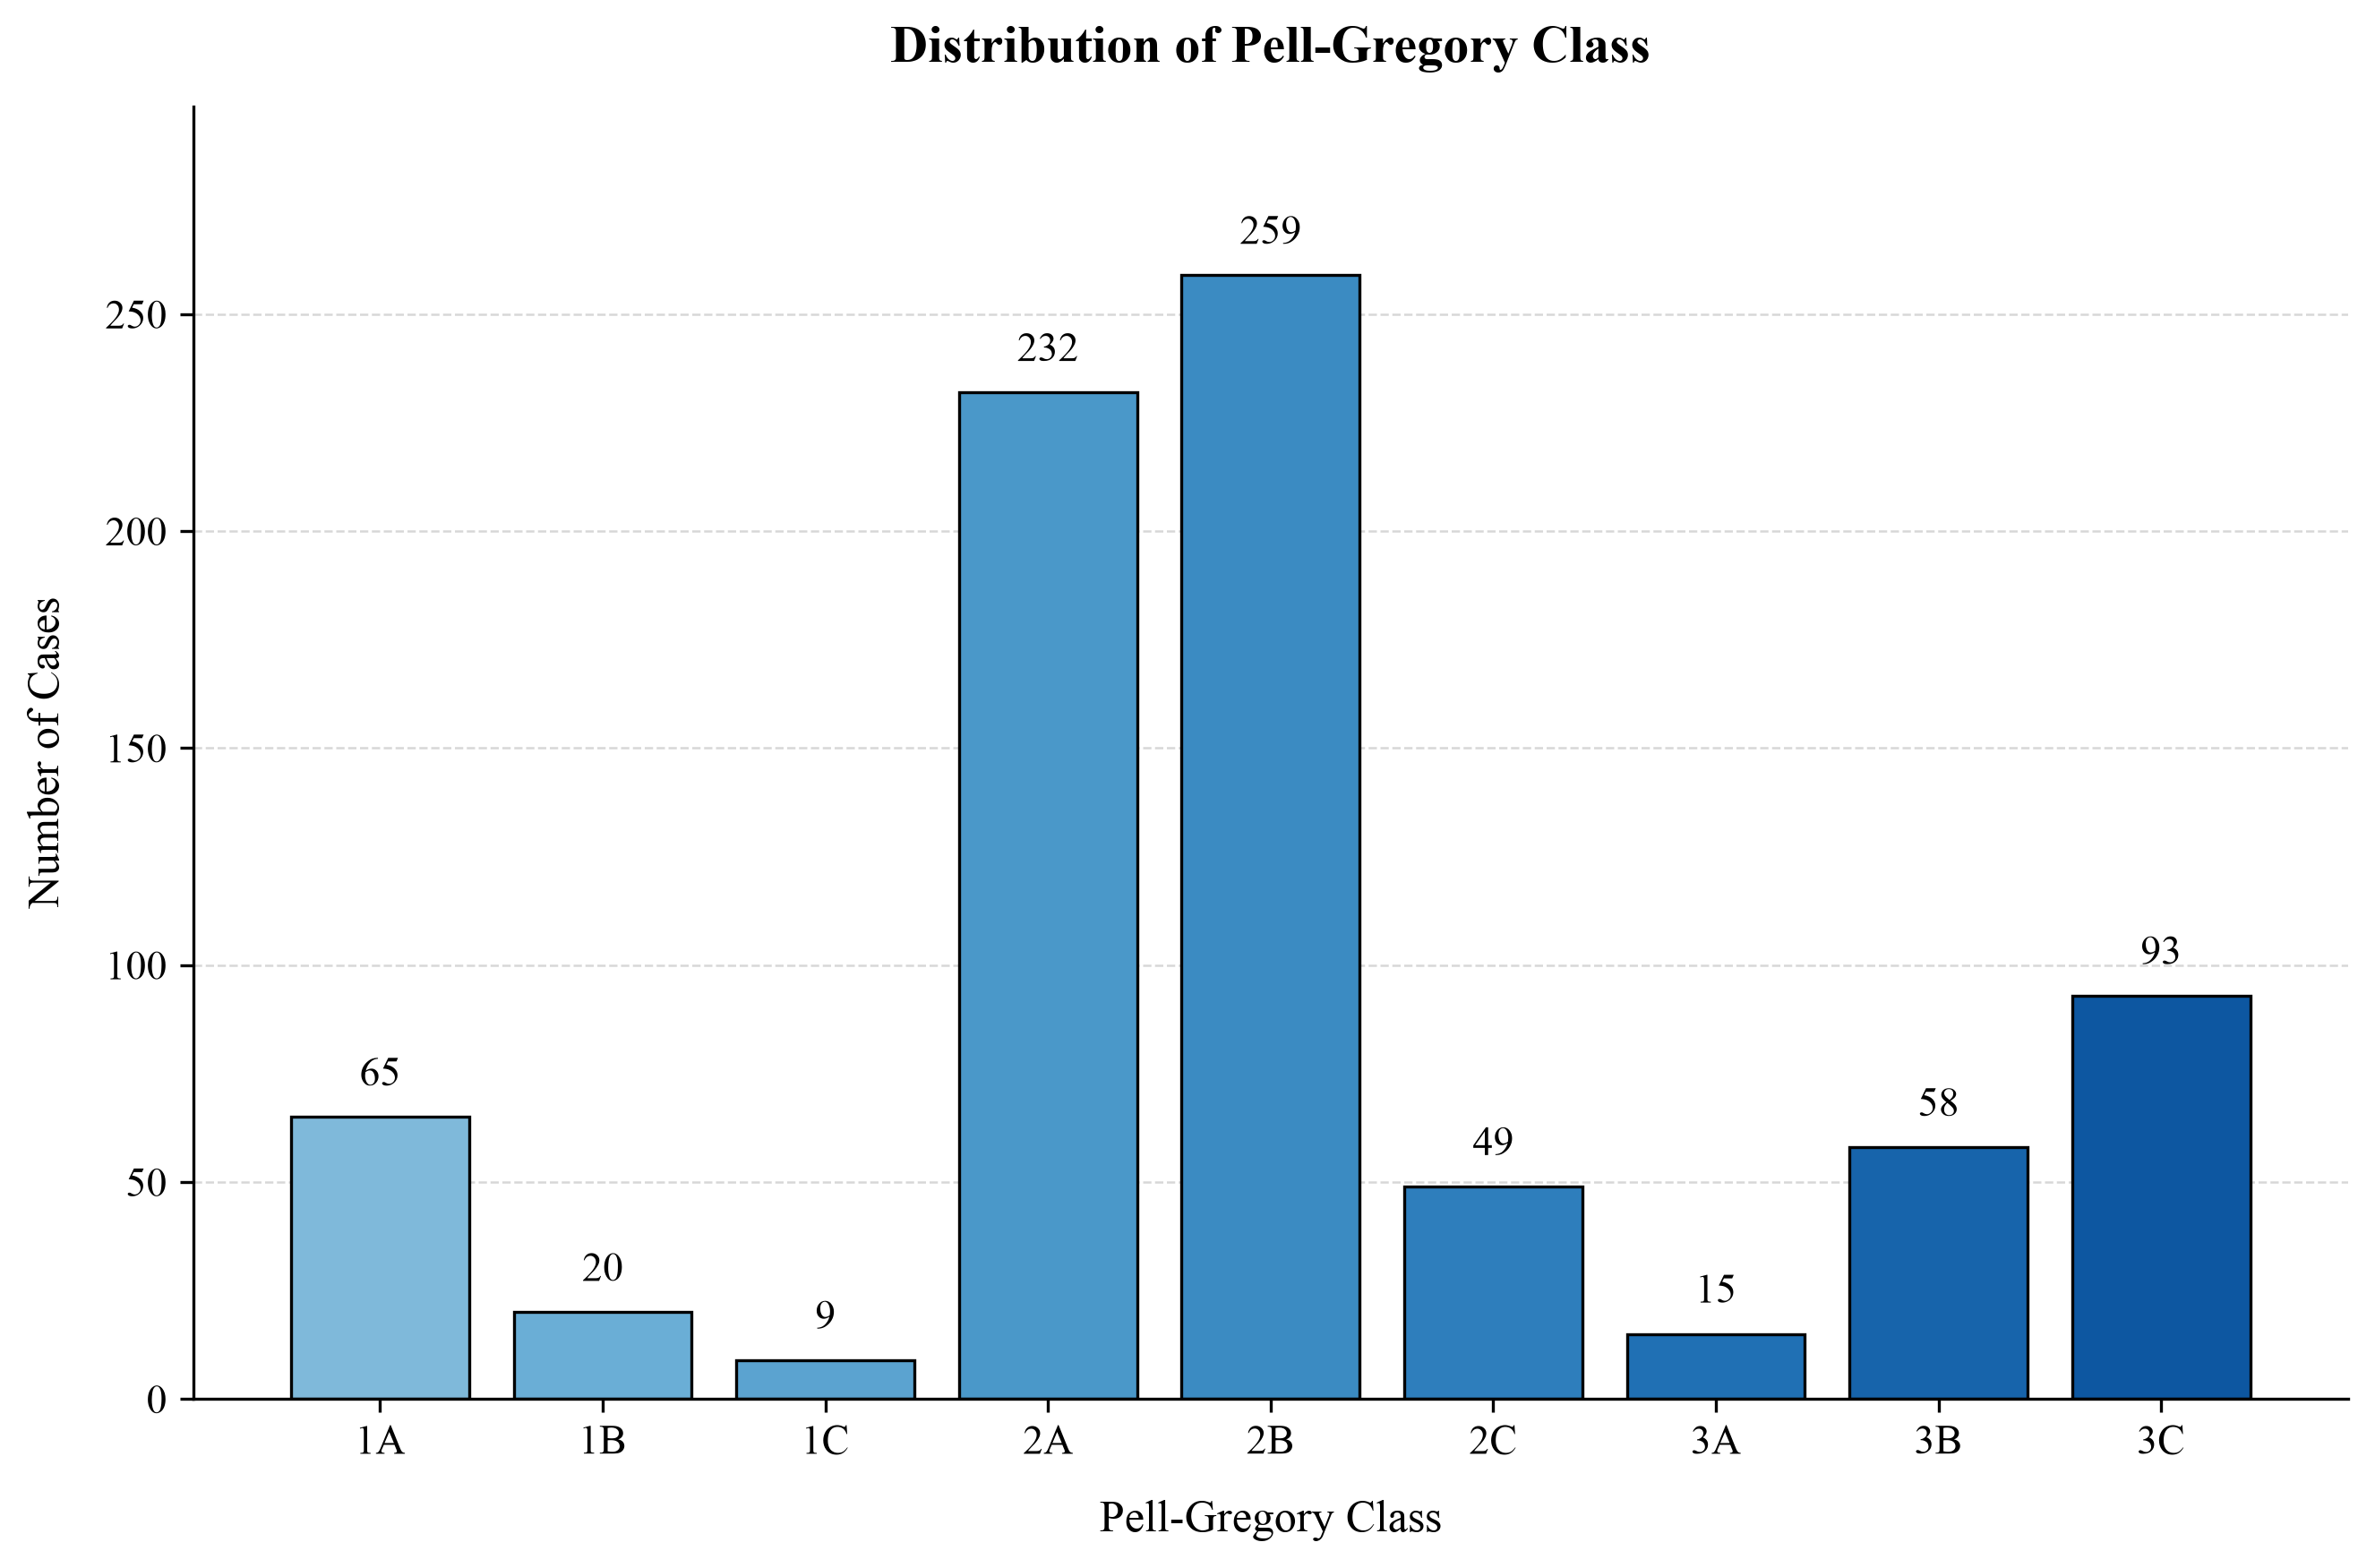

Saved: ../clinical_statistics_outputs/figures/pell_gregory_bar_chart.png


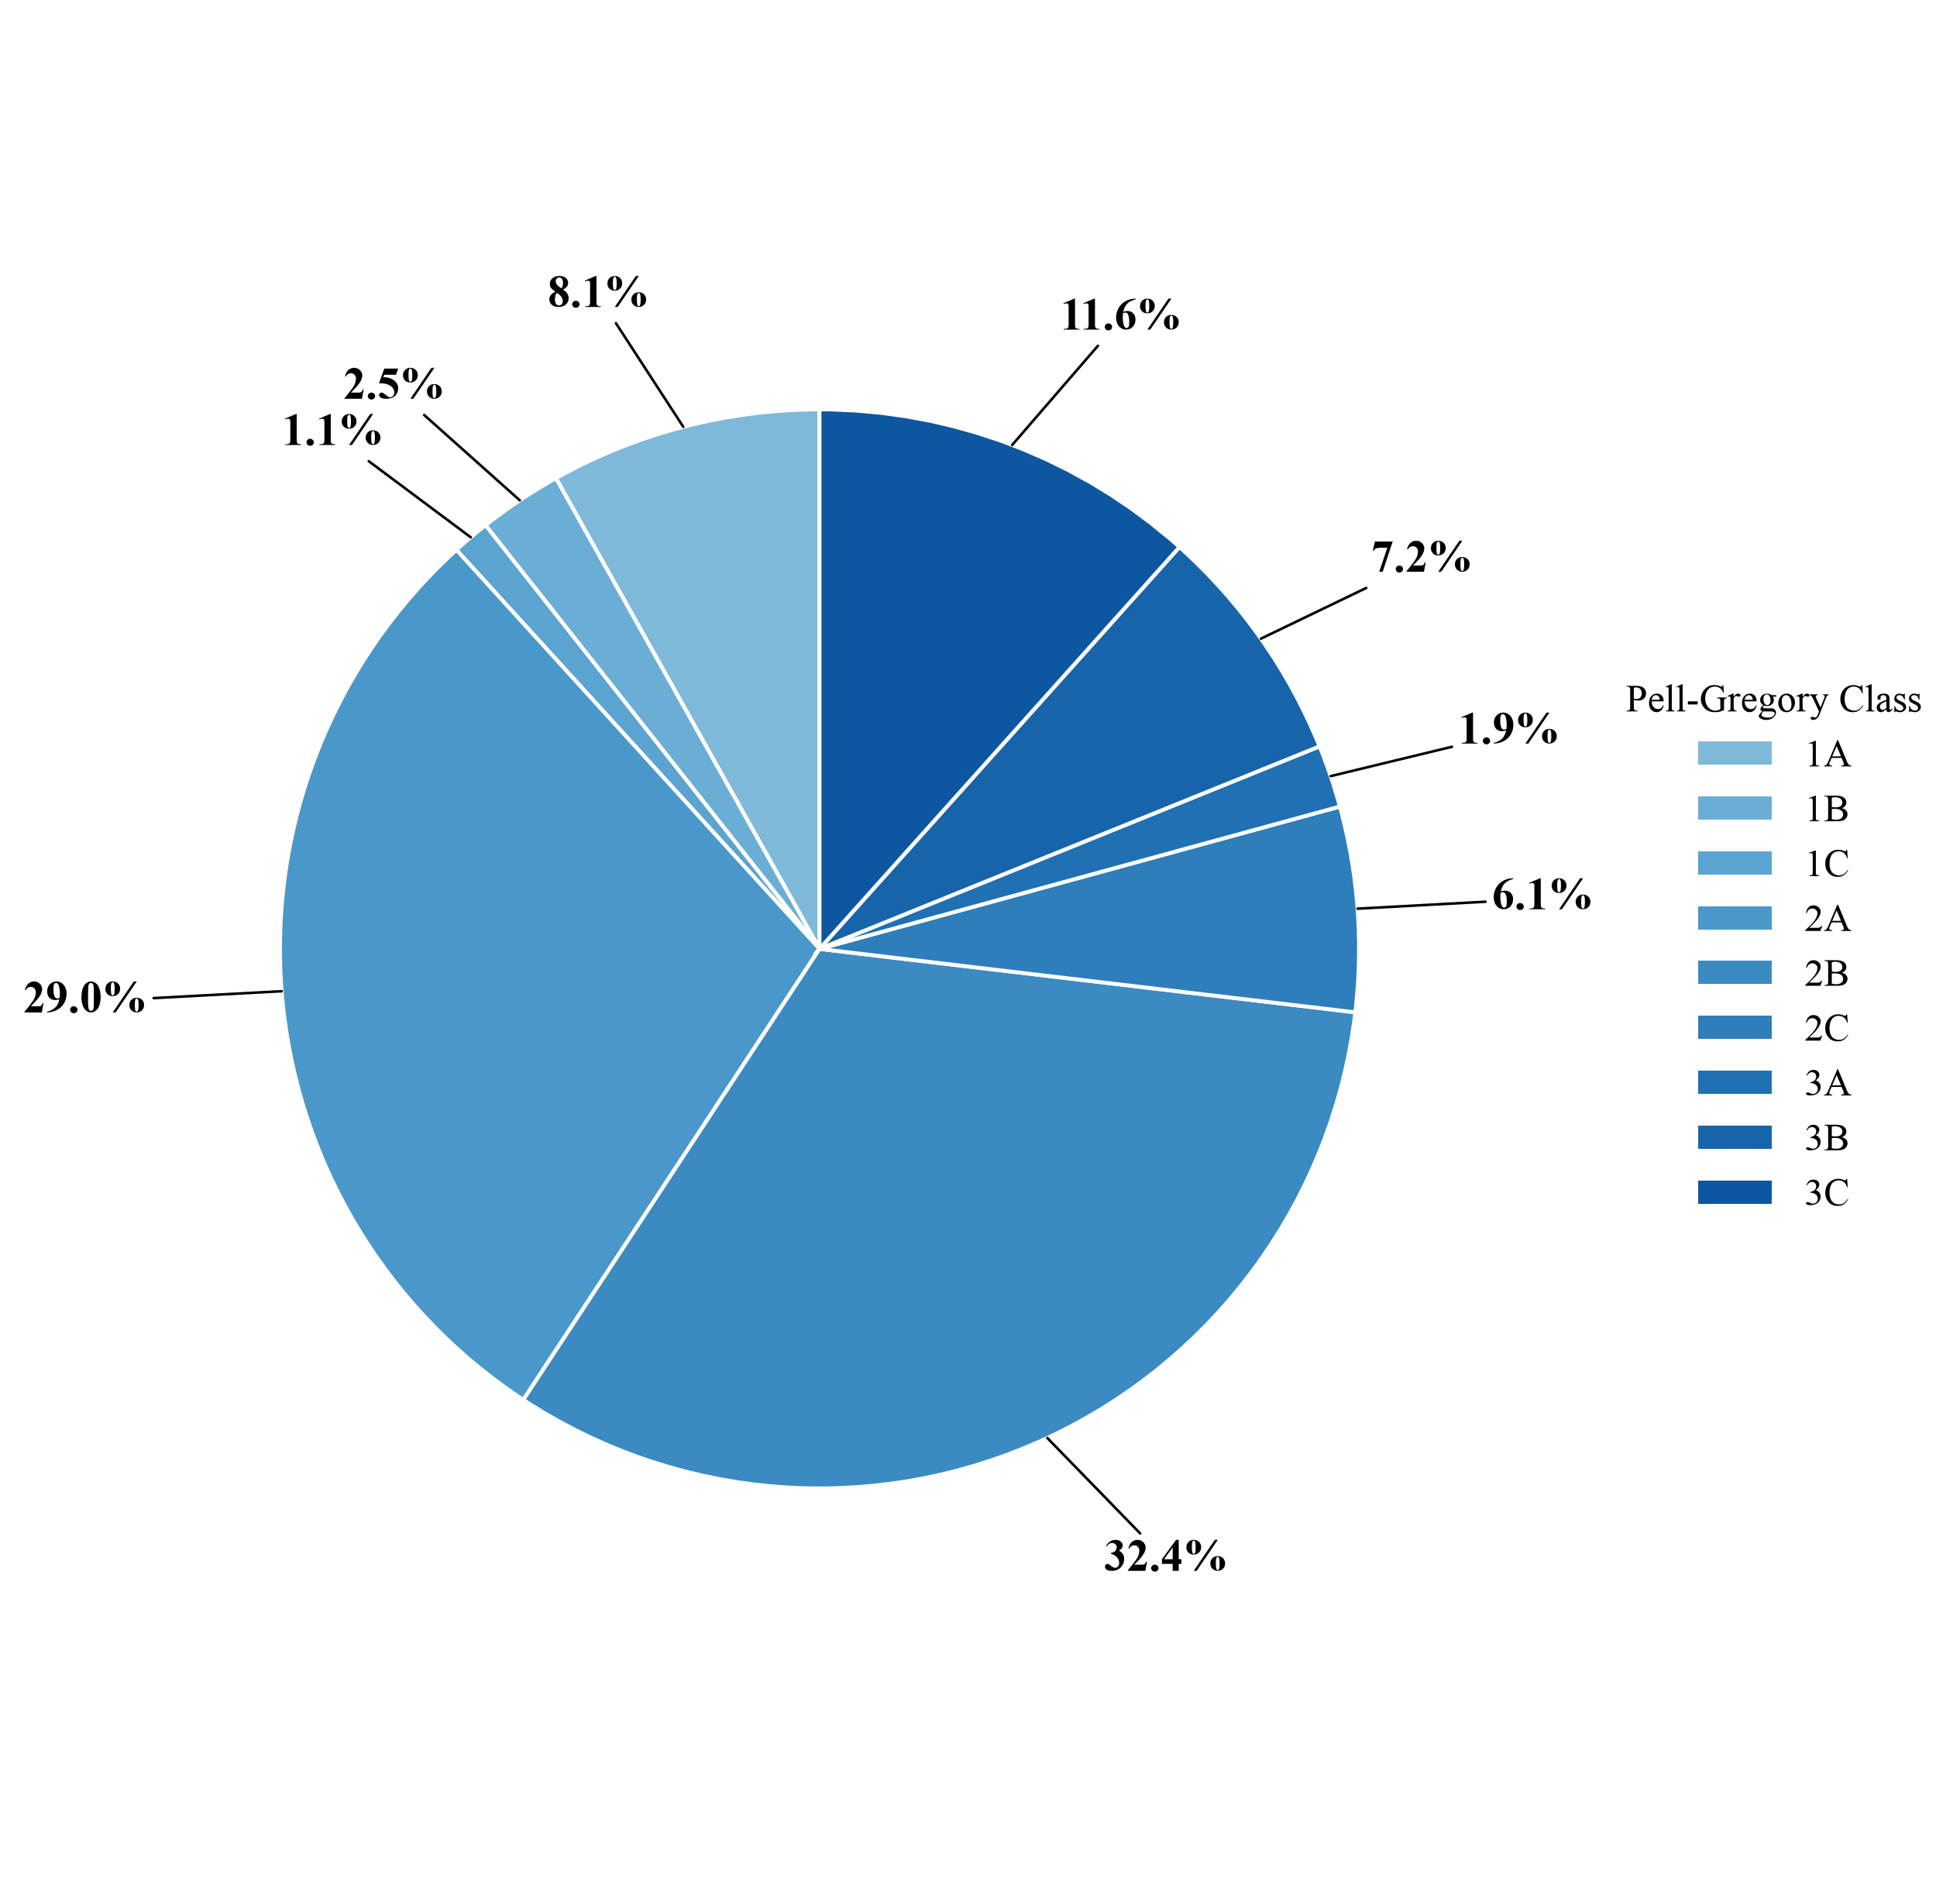

Saved: ../clinical_statistics_outputs/figures/pell_gregory_pie_chart.png
LAB: Winter Angulation Type
COL:winter_angulation

Winter Angulation Type Frequency Table
                   Count  Percentage (%)
winter_angulation                       
Mesioangular         334           41.75
Vertical             214           26.75
Horizontal           203           25.37
Distoangular          49            6.12


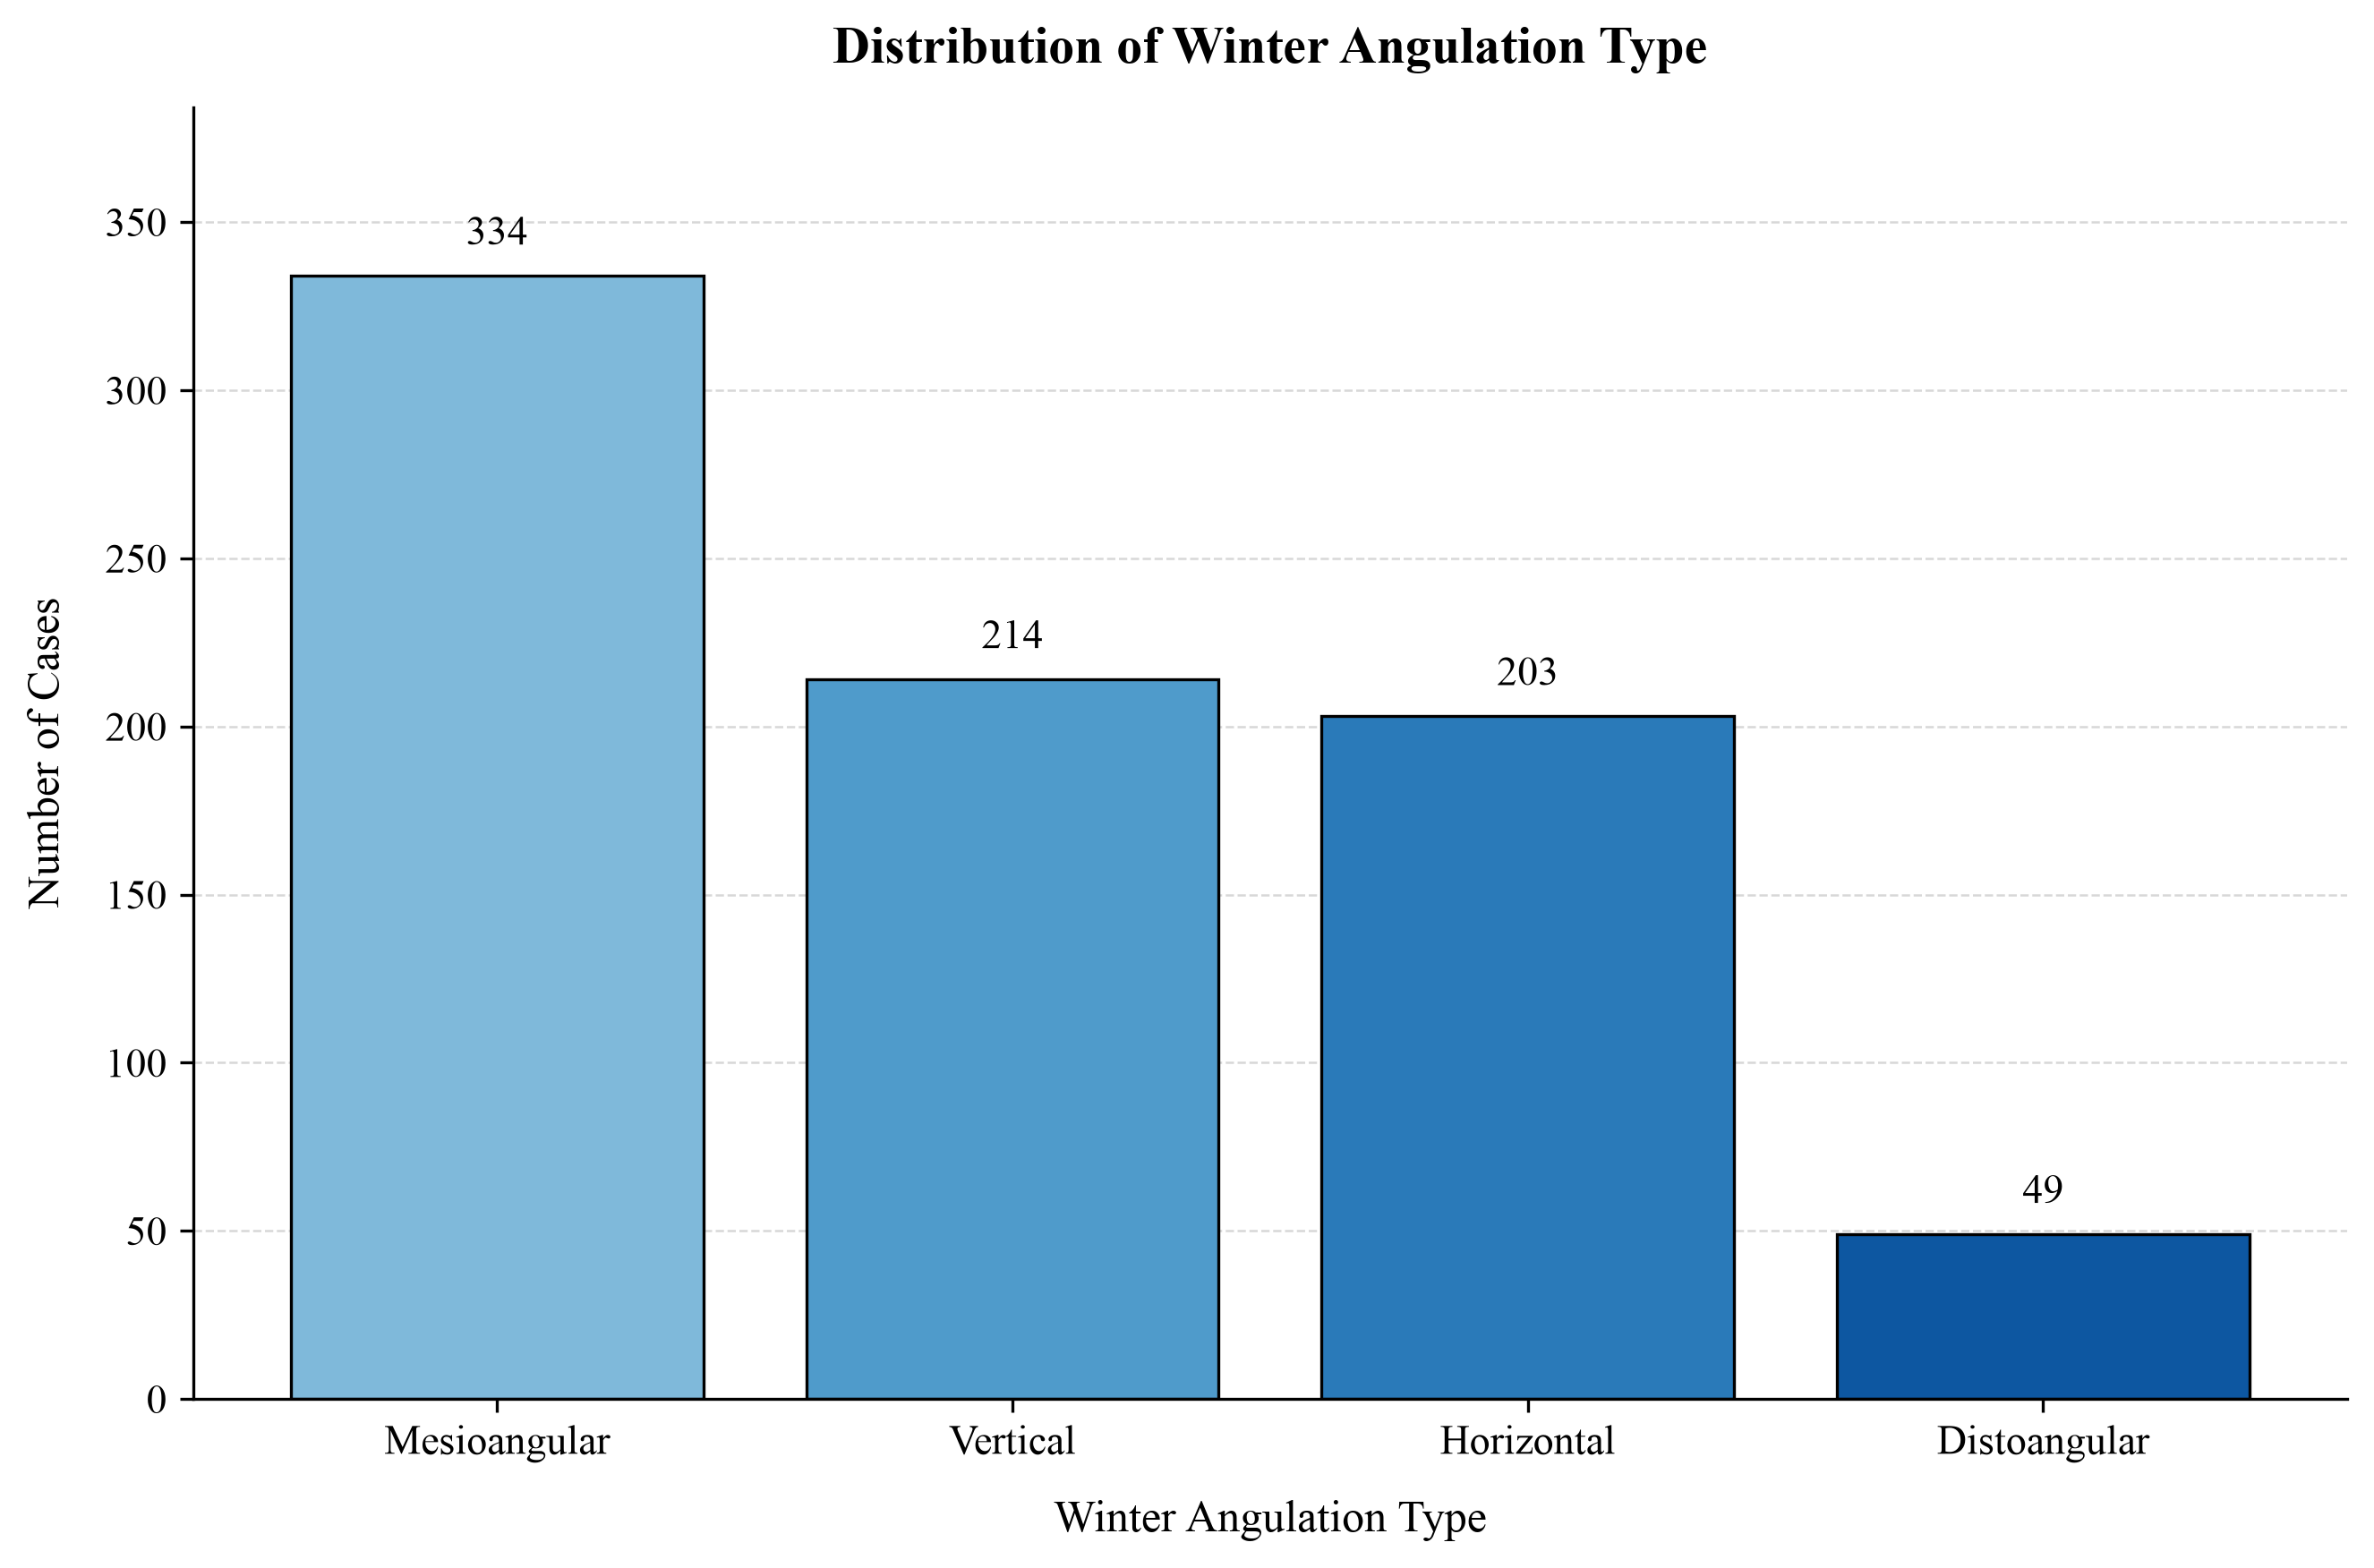

Saved: ../clinical_statistics_outputs/figures/winter_angulation_bar_chart.png


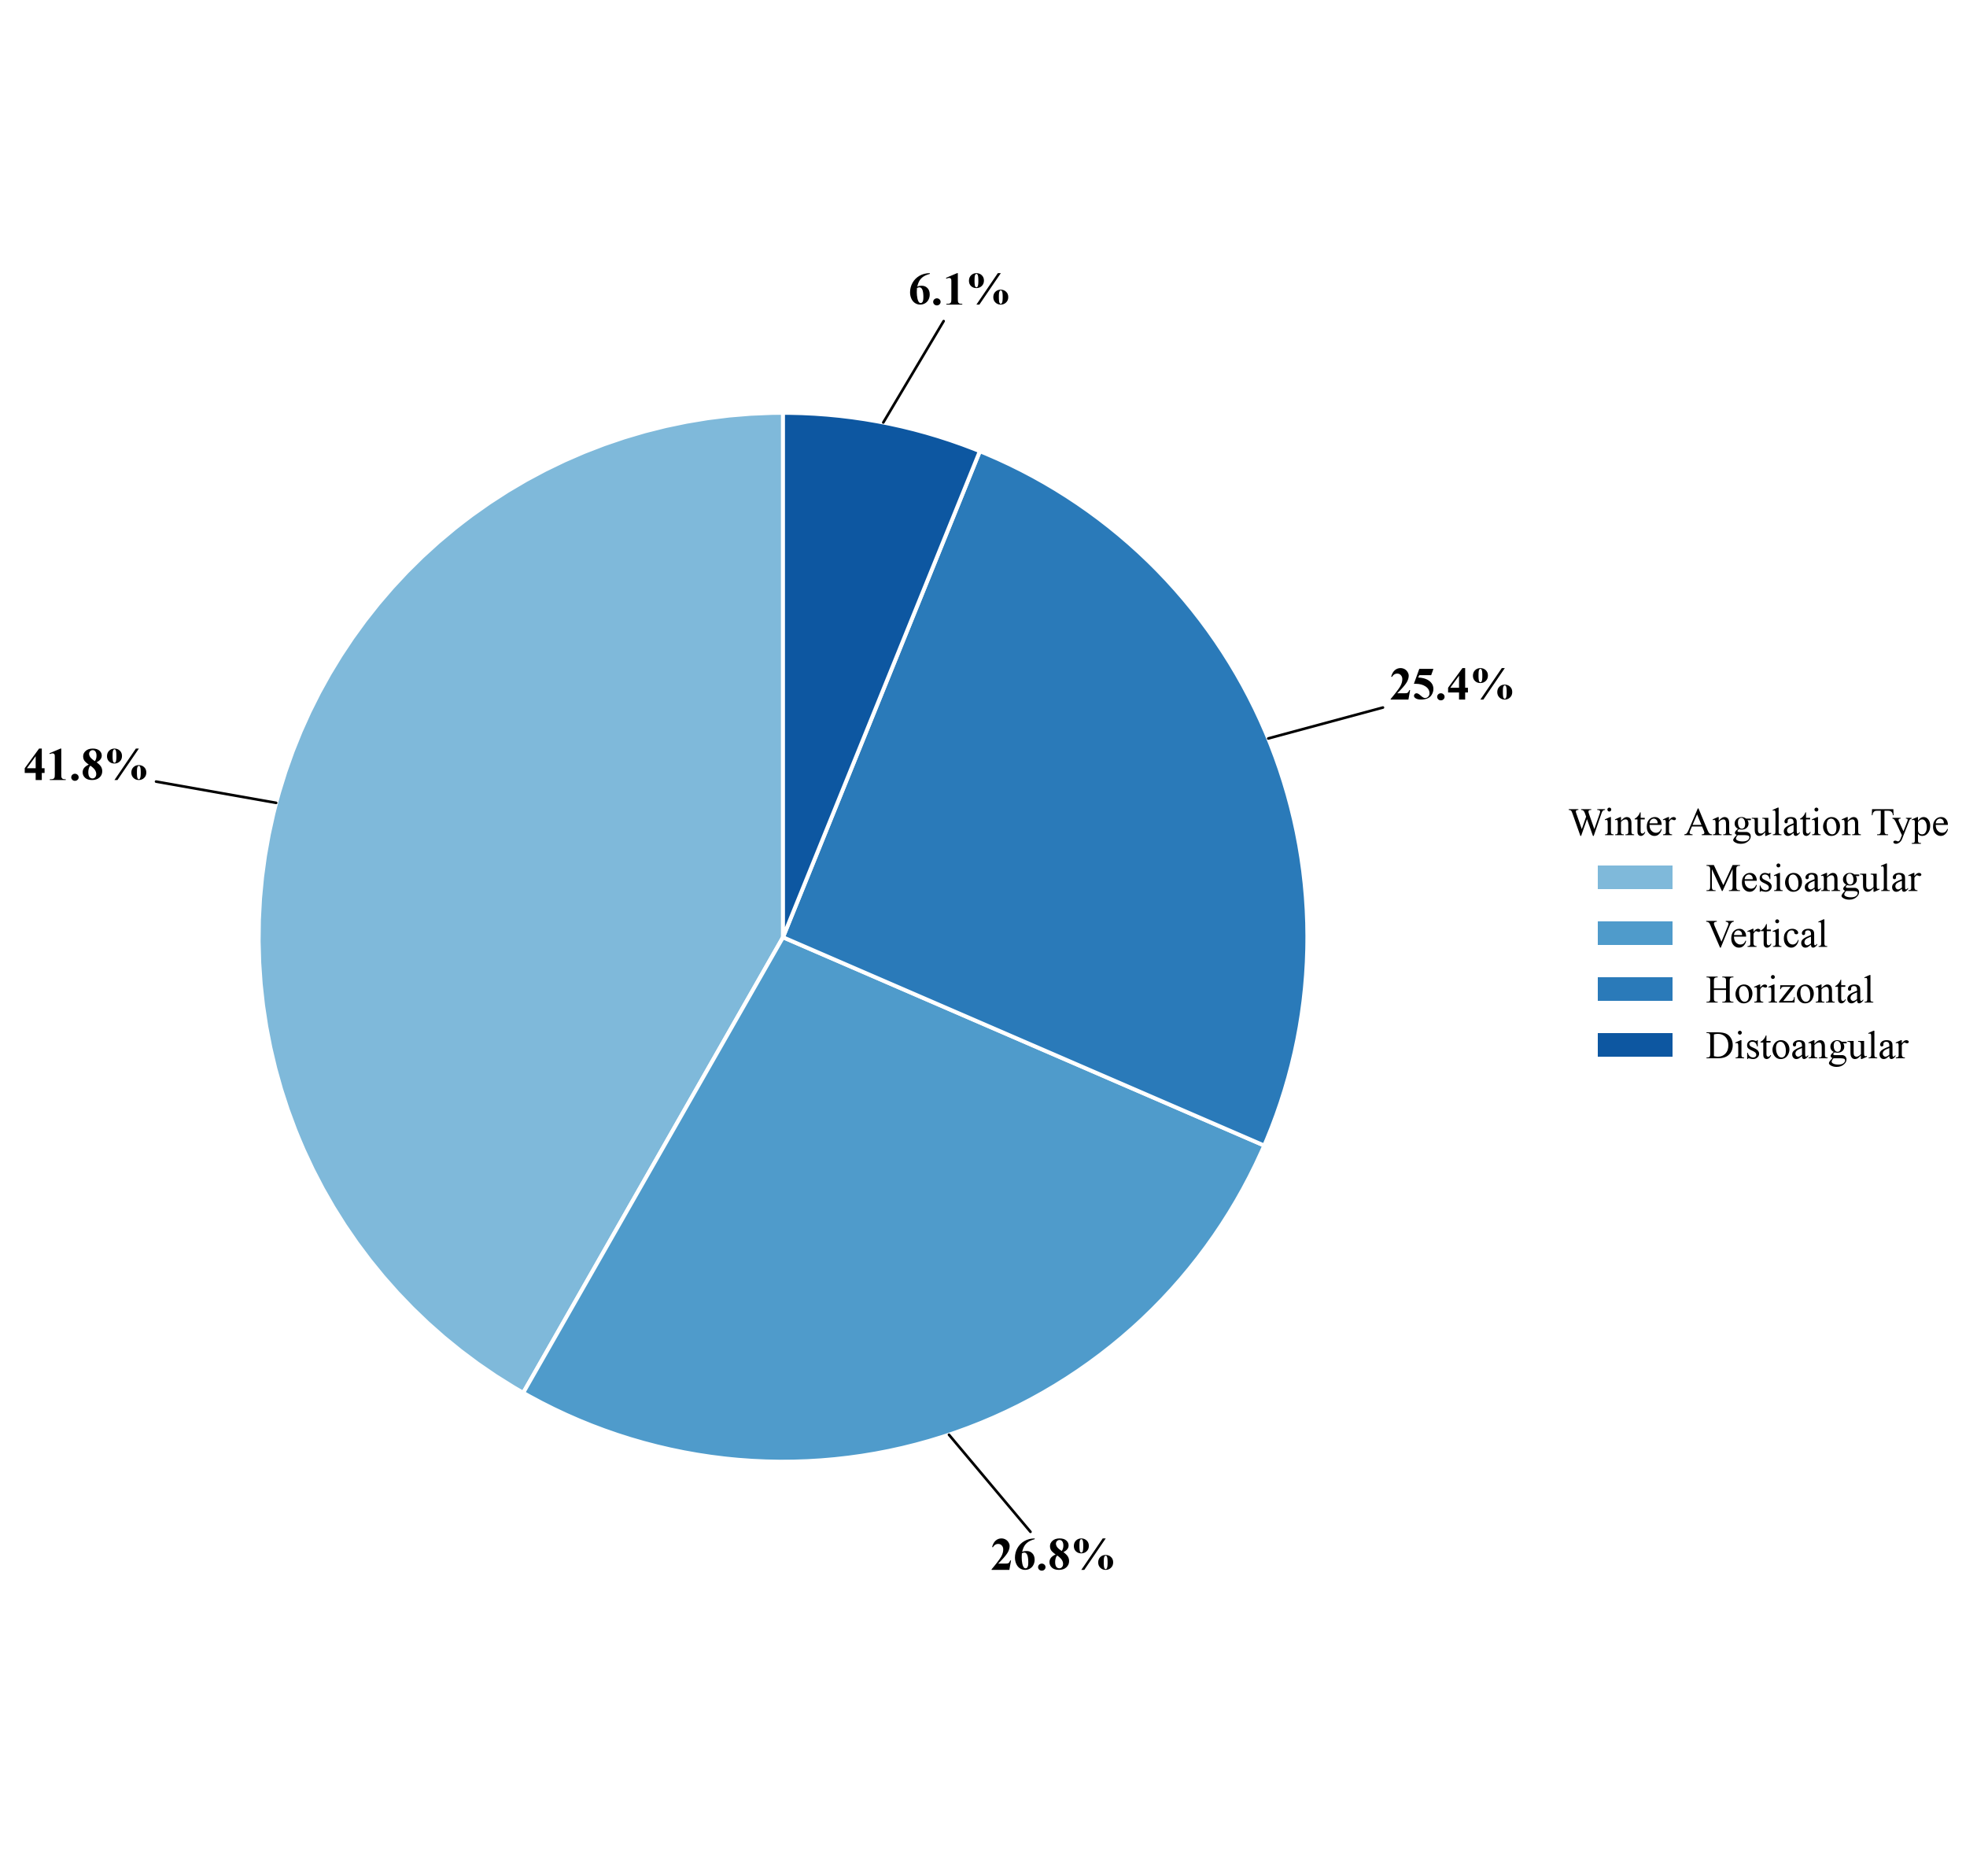

Saved: ../clinical_statistics_outputs/figures/winter_angulation_pie_chart.png
LAB: Side
COL:side

Side Frequency Table
         Count  Percentage (%)
side                          
left       400            50.0
right      400            50.0
unknown      0             0.0


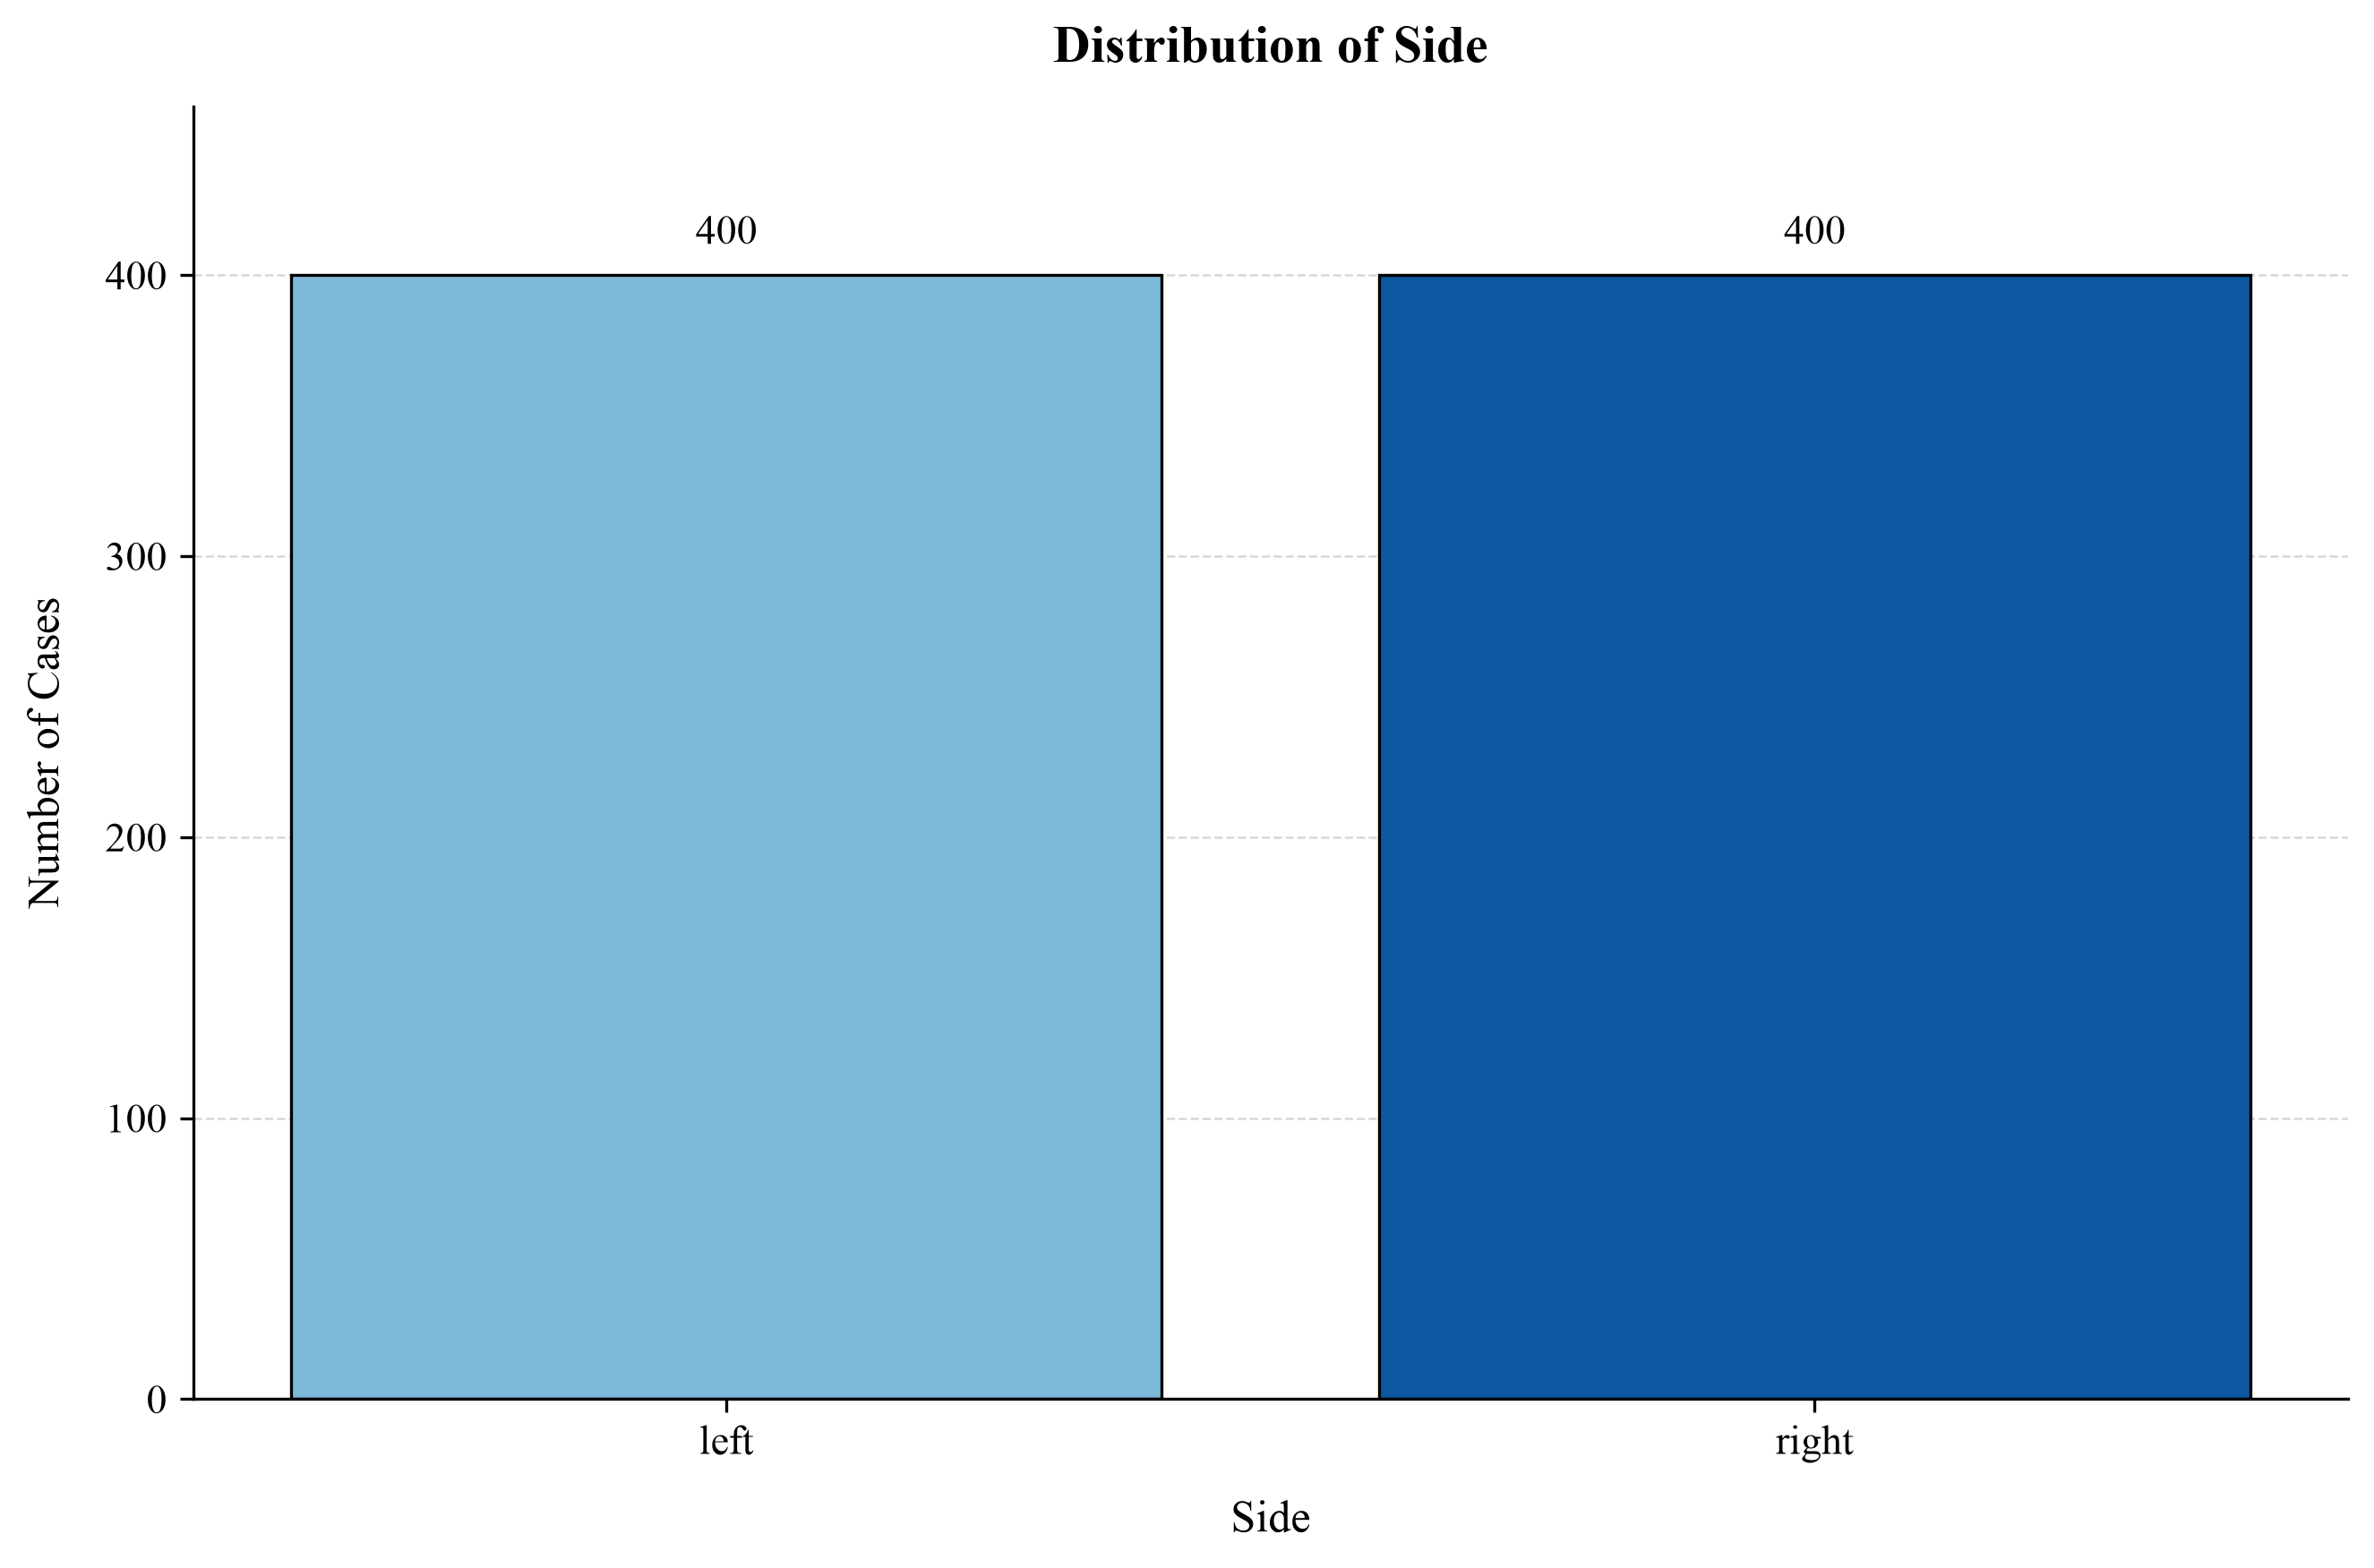

Saved: ../clinical_statistics_outputs/figures/side_bar_chart.png


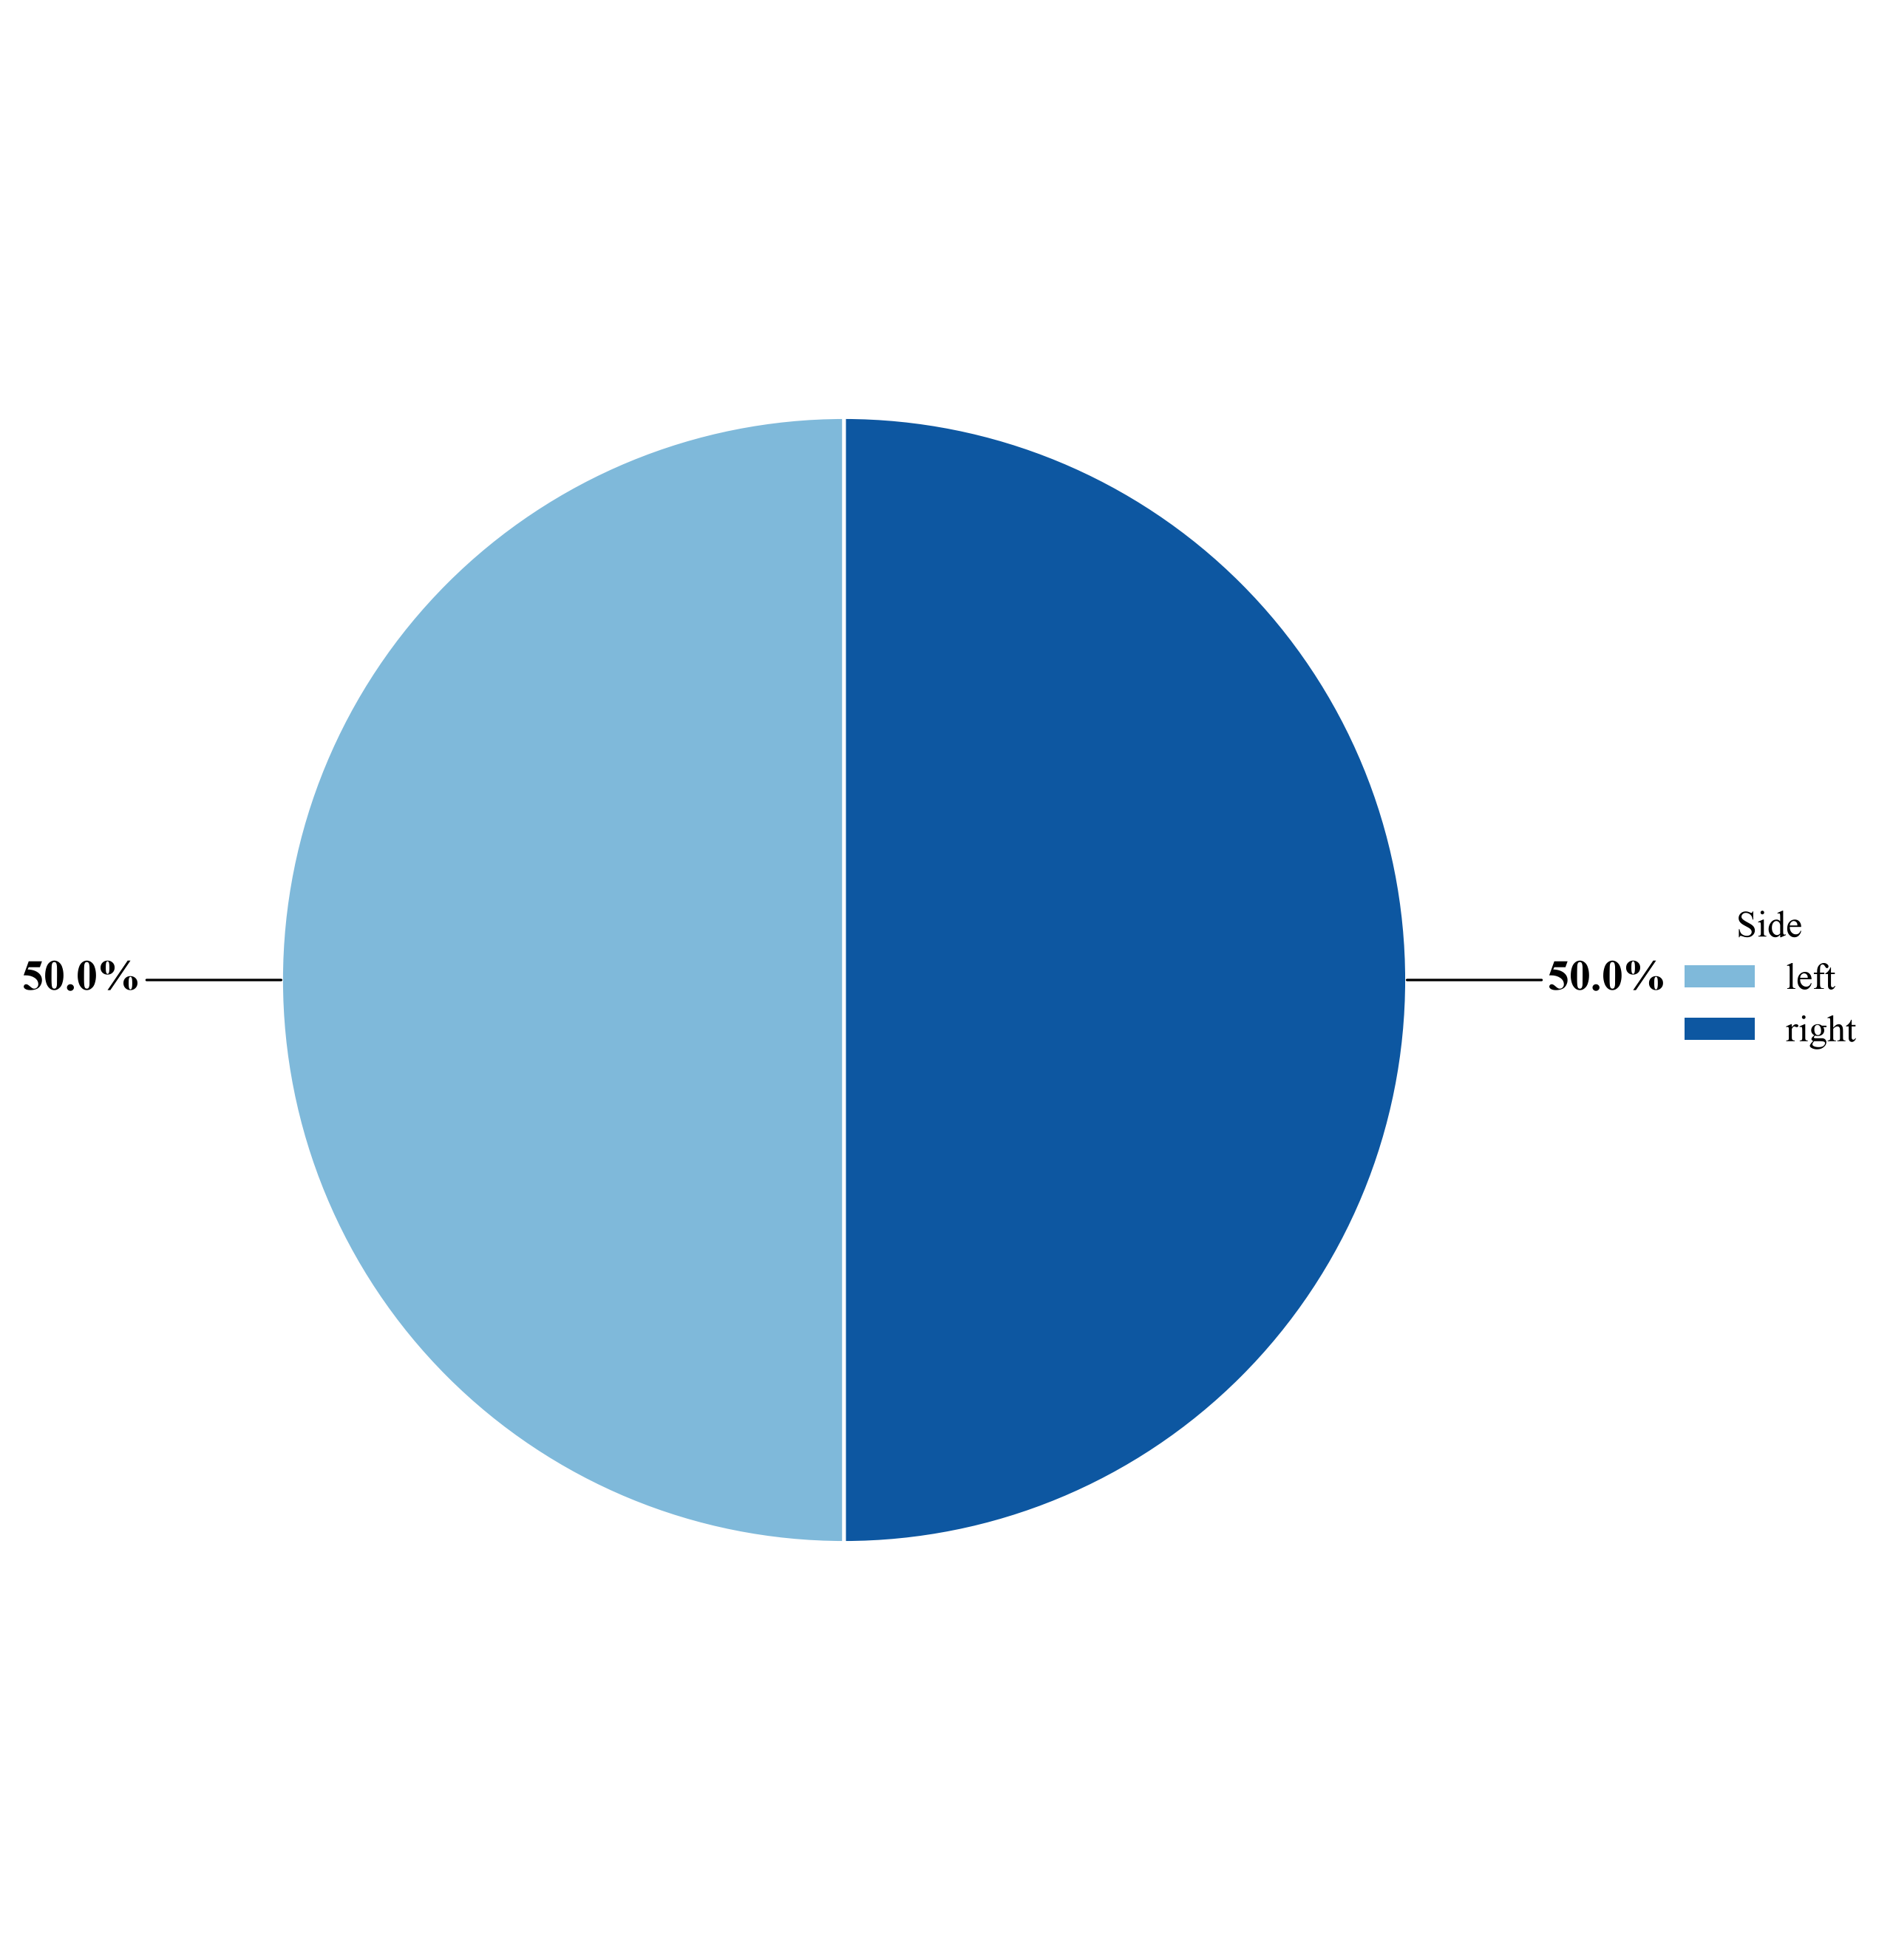

Saved: ../clinical_statistics_outputs/figures/side_pie_chart.png


In [14]:
for column, info in categorical_analysis.items():
    label = info["label"]
    order = info["order"]
    print("LAB: "+ label)
    print("COL:" + column)
    table = save_frequency_table(
        df_clinical,
        column,
        label,
        order
    )

    counts = table["Count"]
    plot_bar(counts, column, label)
    plot_pie(counts, column, label)


Pederson Score Descriptive Statistics
-------------------------------------
count    800.000000
mean       5.861250
std        1.155928
min        3.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: pederson, dtype: float64

Pederson Score Frequency Table
          Count  Percentage (%)
pederson                       
6           258           32.25
5           229           28.62
7           175           21.88
4            61            7.62
8            53            6.62
3            19            2.38
9             4            0.50
10            1            0.12


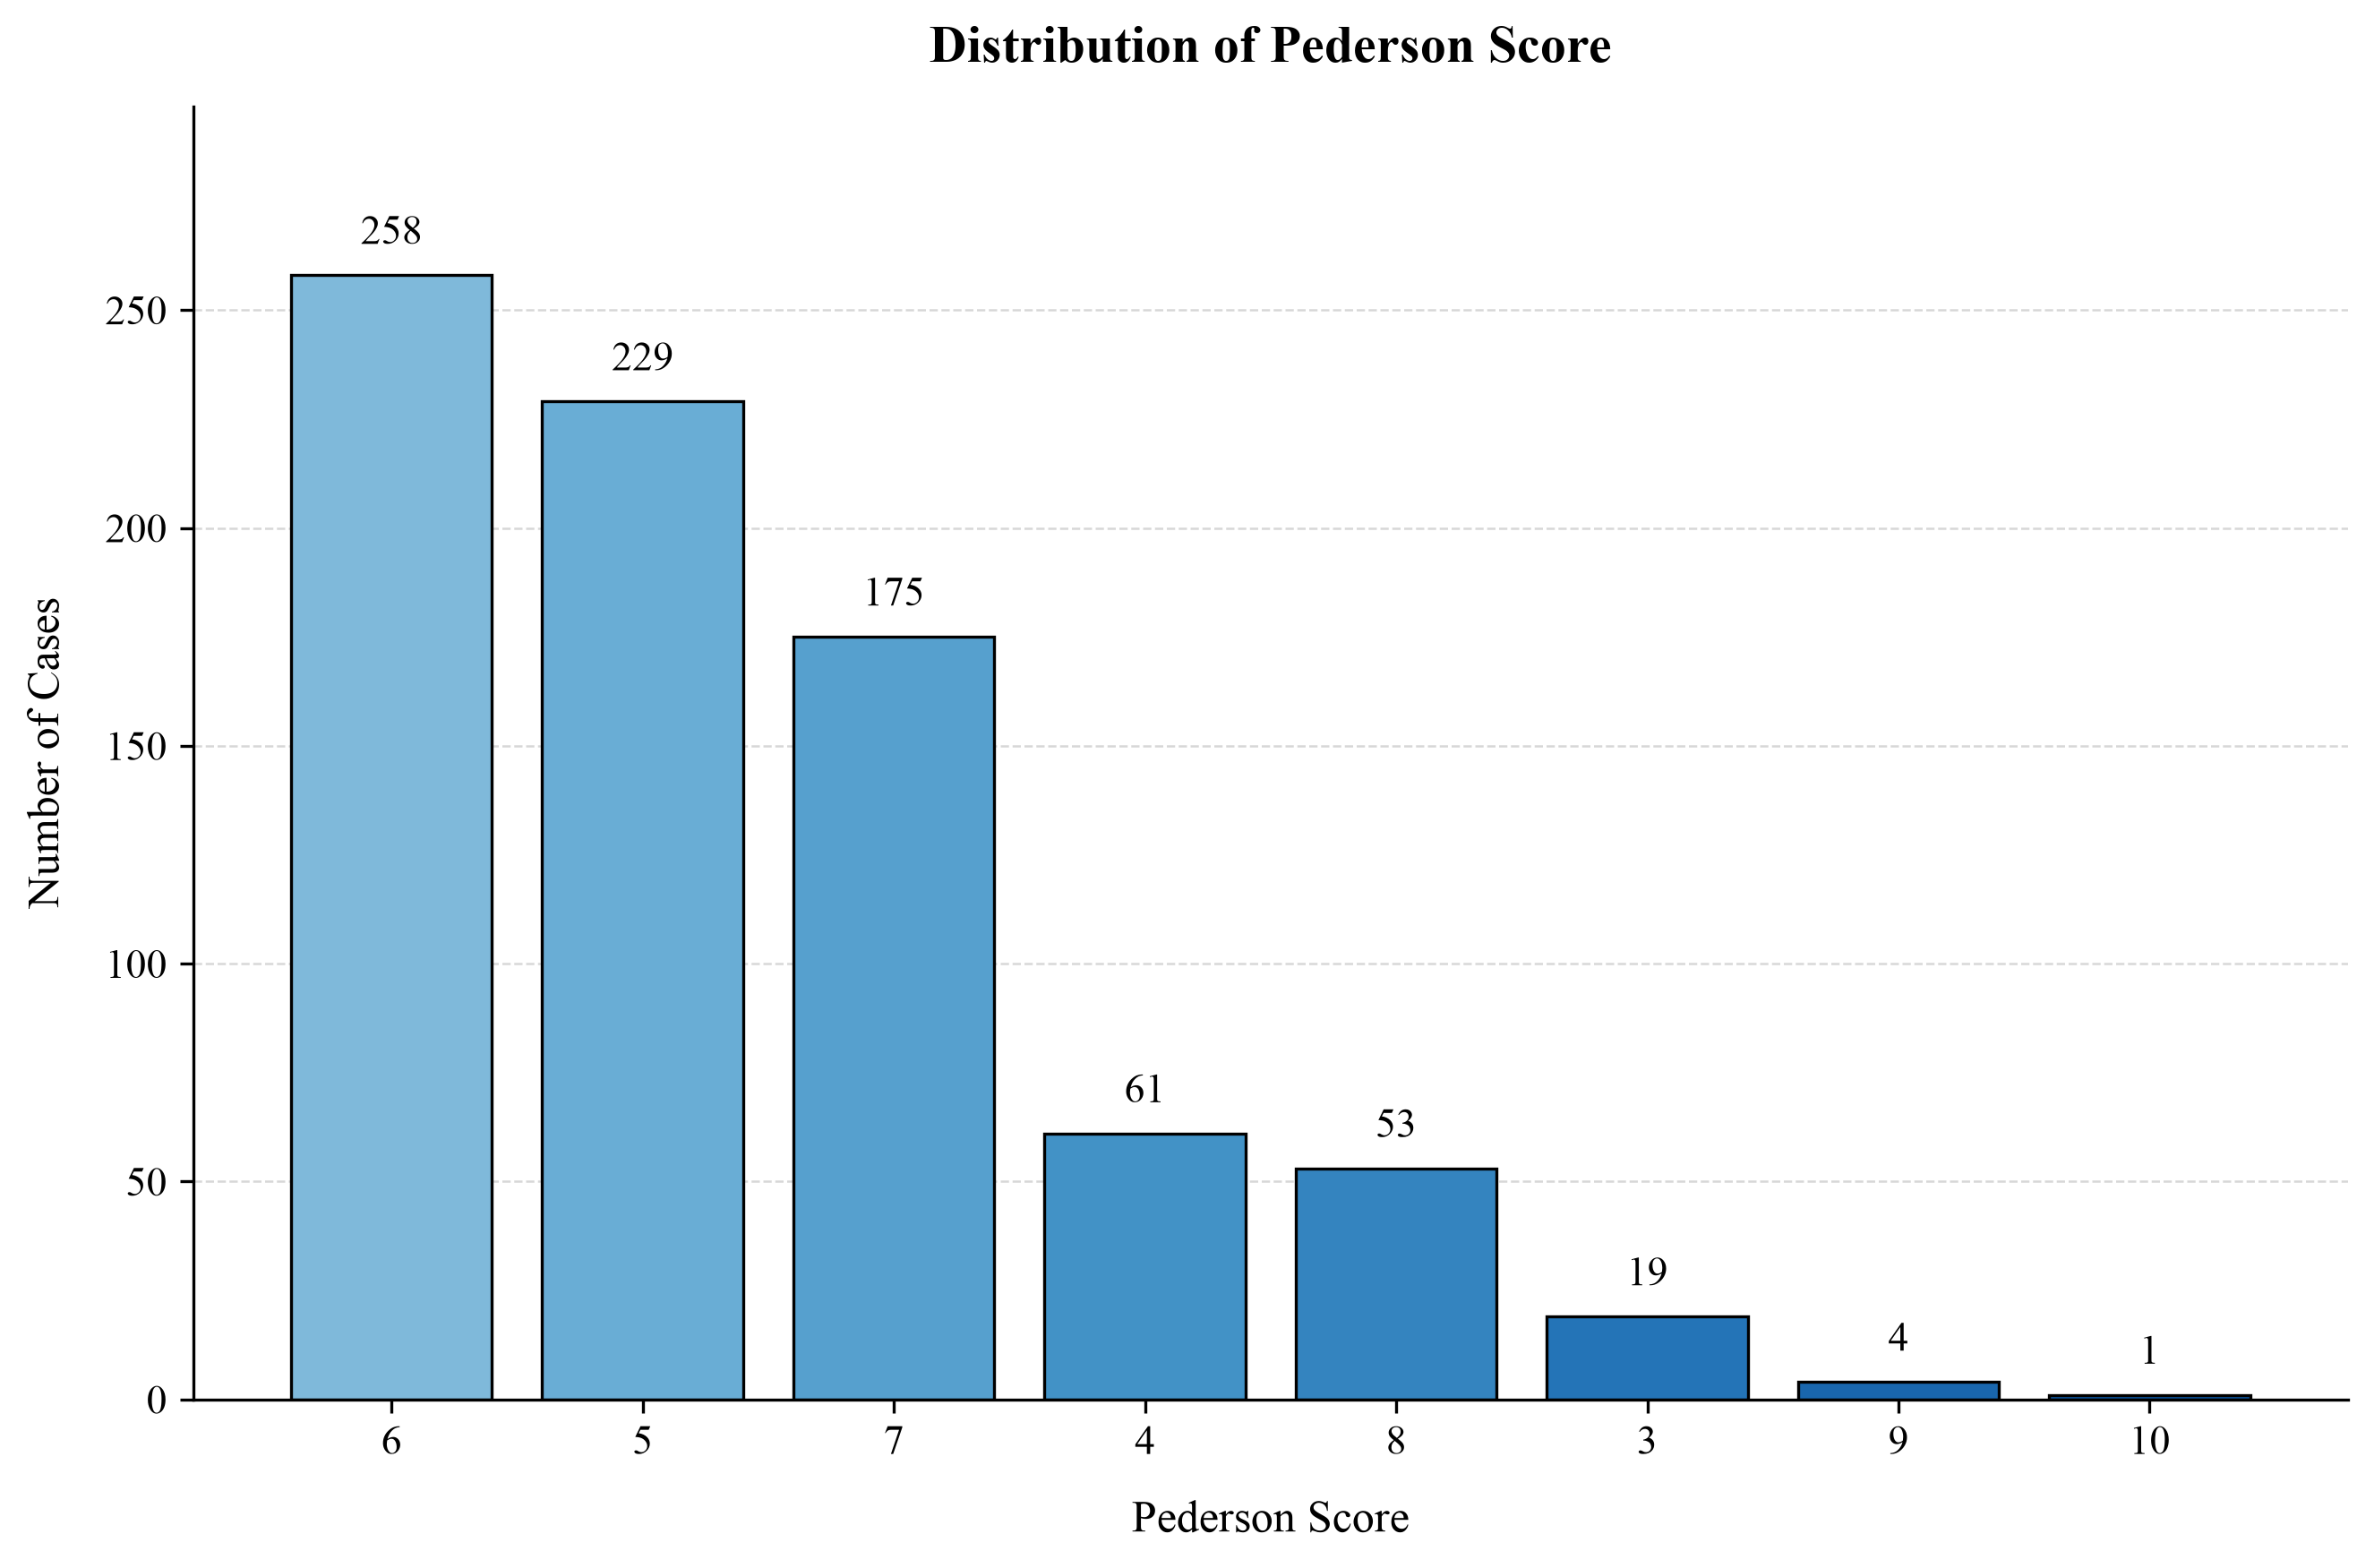

Saved: ../clinical_statistics_outputs/figures/pederson_bar_chart.png


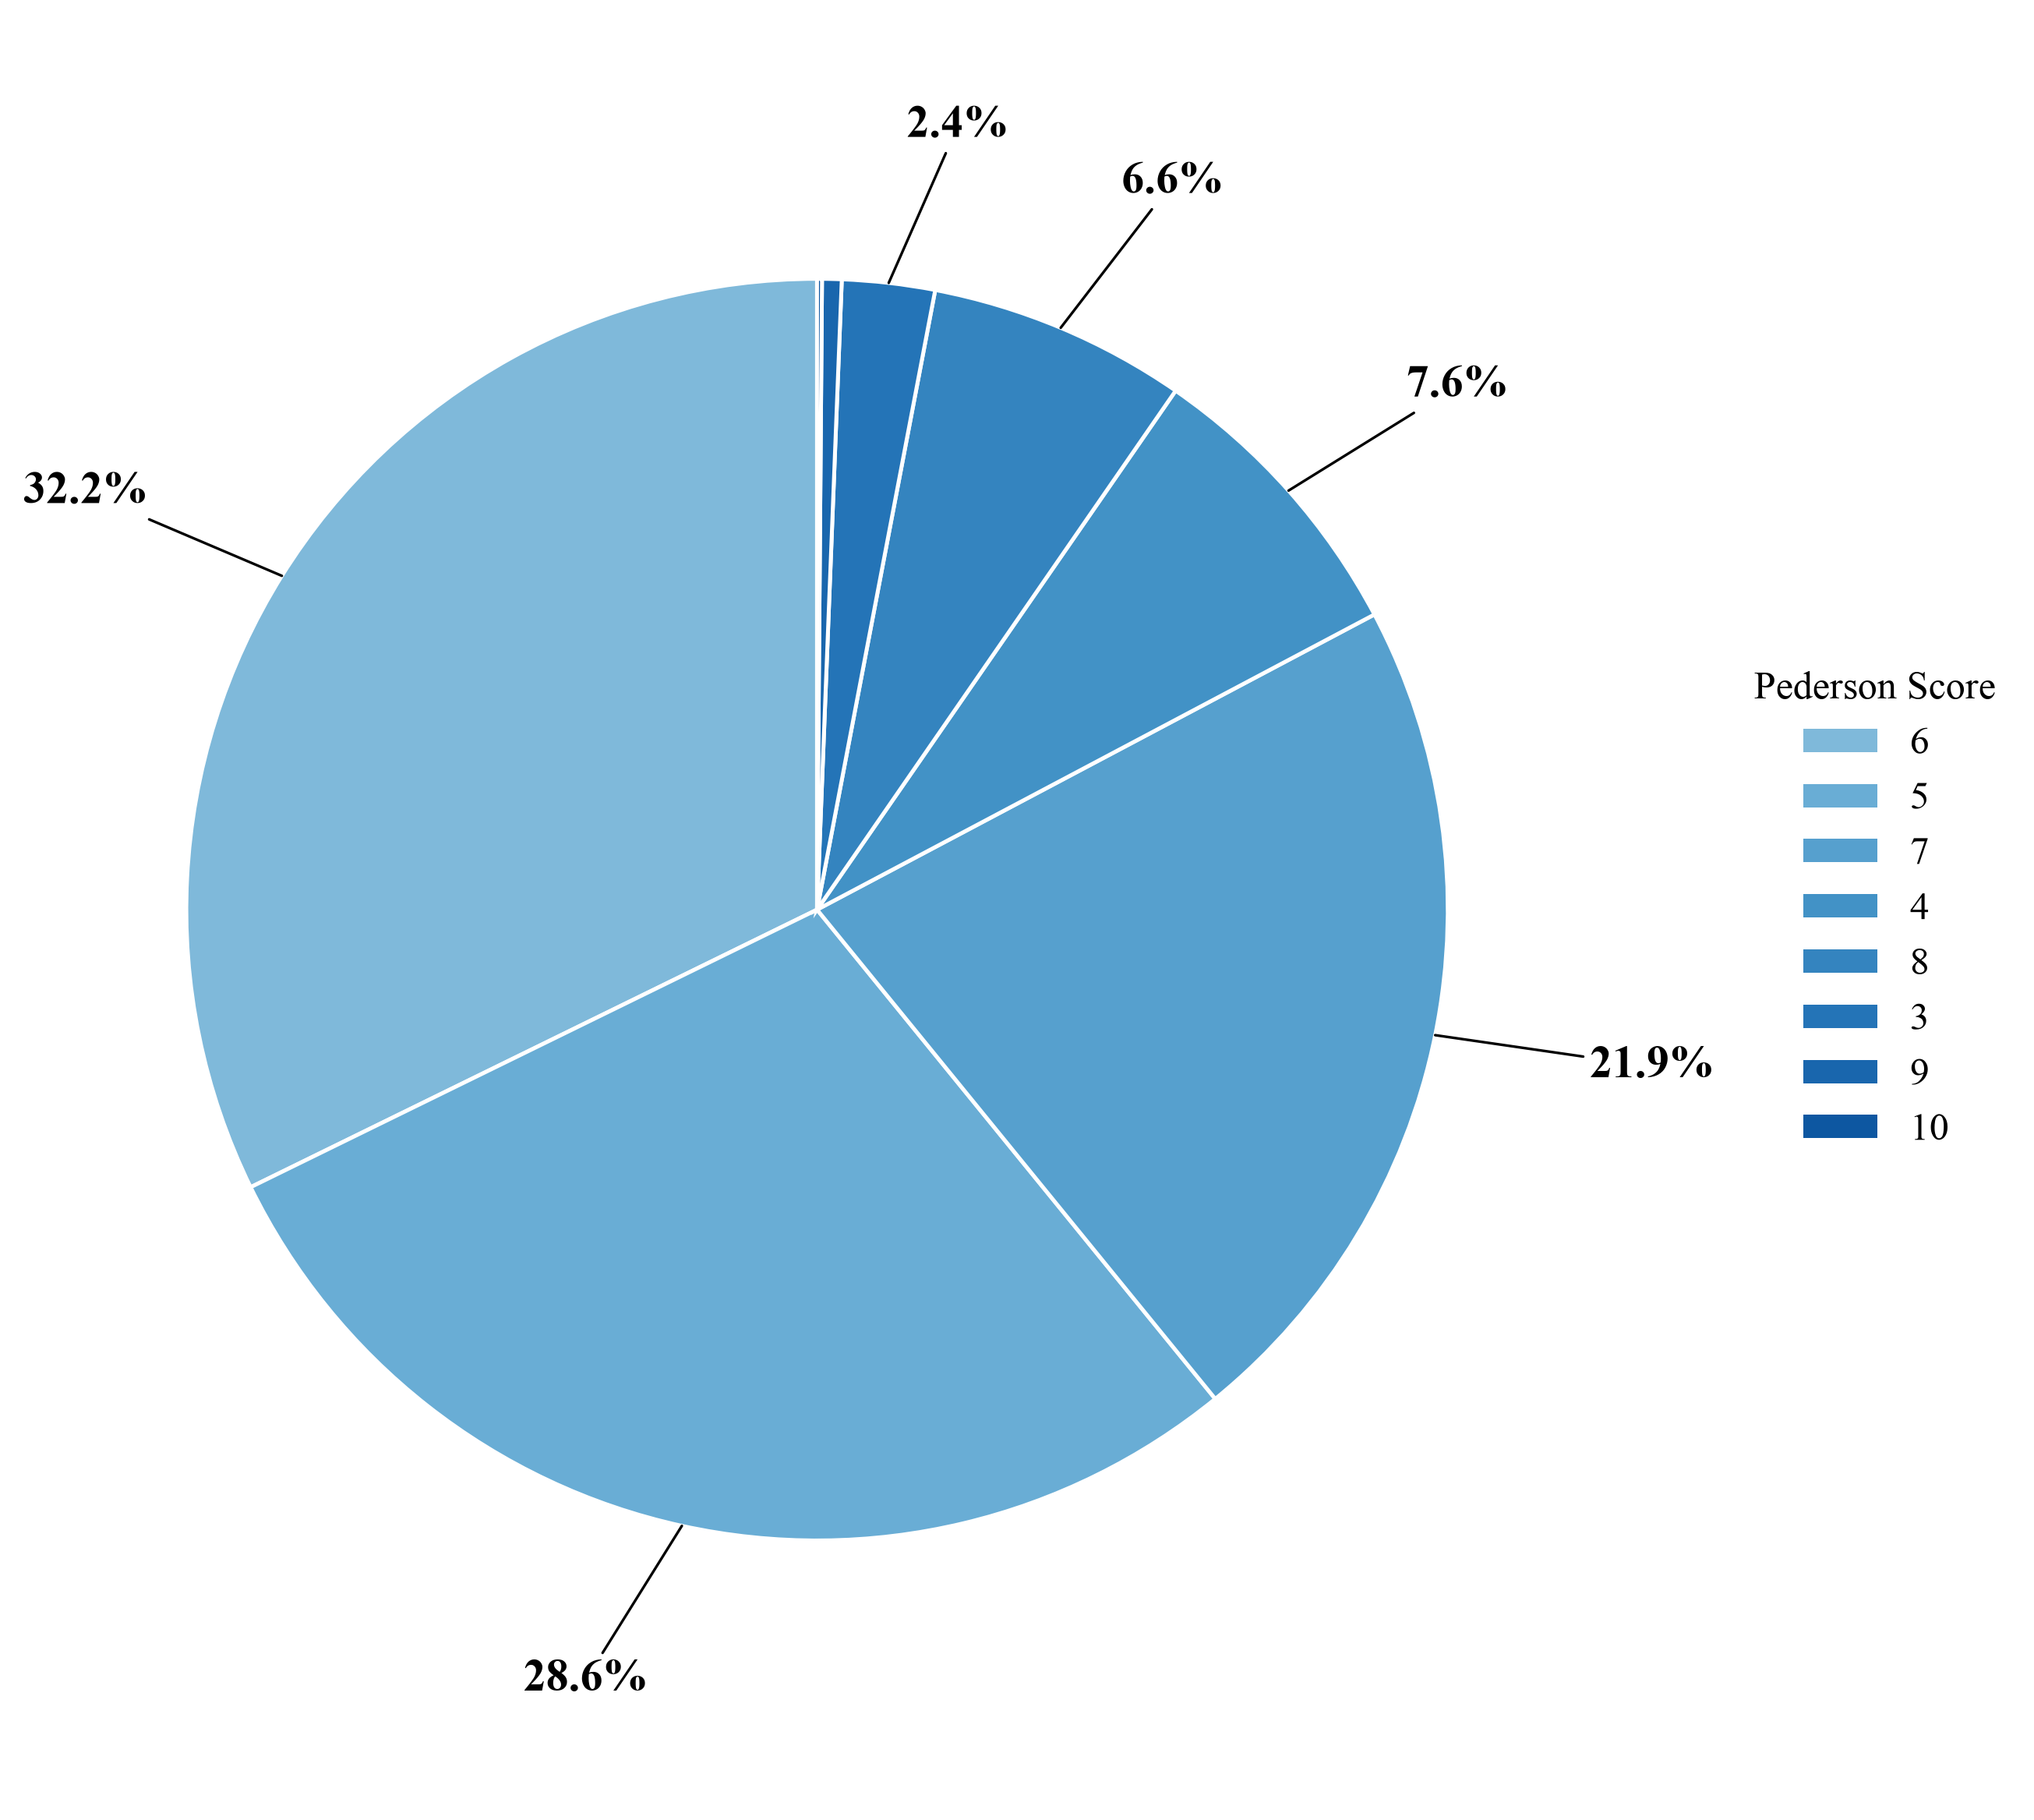

Saved: ../clinical_statistics_outputs/figures/pederson_pie_chart.png


In [16]:
# ============================================================
# 8. Pederson score statistics
# ============================================================

pederson_stats = df_clinical["pederson"].describe()

print("\nPederson Score Descriptive Statistics")
print("-------------------------------------")
print(pederson_stats)

pederson_stats.to_csv(
    os.path.join(tables_folder, "pederson_descriptive_statistics.csv")
)

# Frequency table for Pederson scores
pederson_table = save_frequency_table(
    df_clinical.dropna(subset=["pederson"]),
    "pederson",
    "Pederson Score",
    order=None
)

plot_bar(
    pederson_table["Count"],
    "pederson",
    "Pederson Score"
)

plot_pie(
    pederson_table["Count"],
    "pederson",
    "Pederson Score"
)


Pederson Difficulty Level Frequency Table
                     Count  Percentage (%)
pederson_difficulty                       
Easy                    80           10.00
Moderate               487           60.88
Difficult              233           29.12


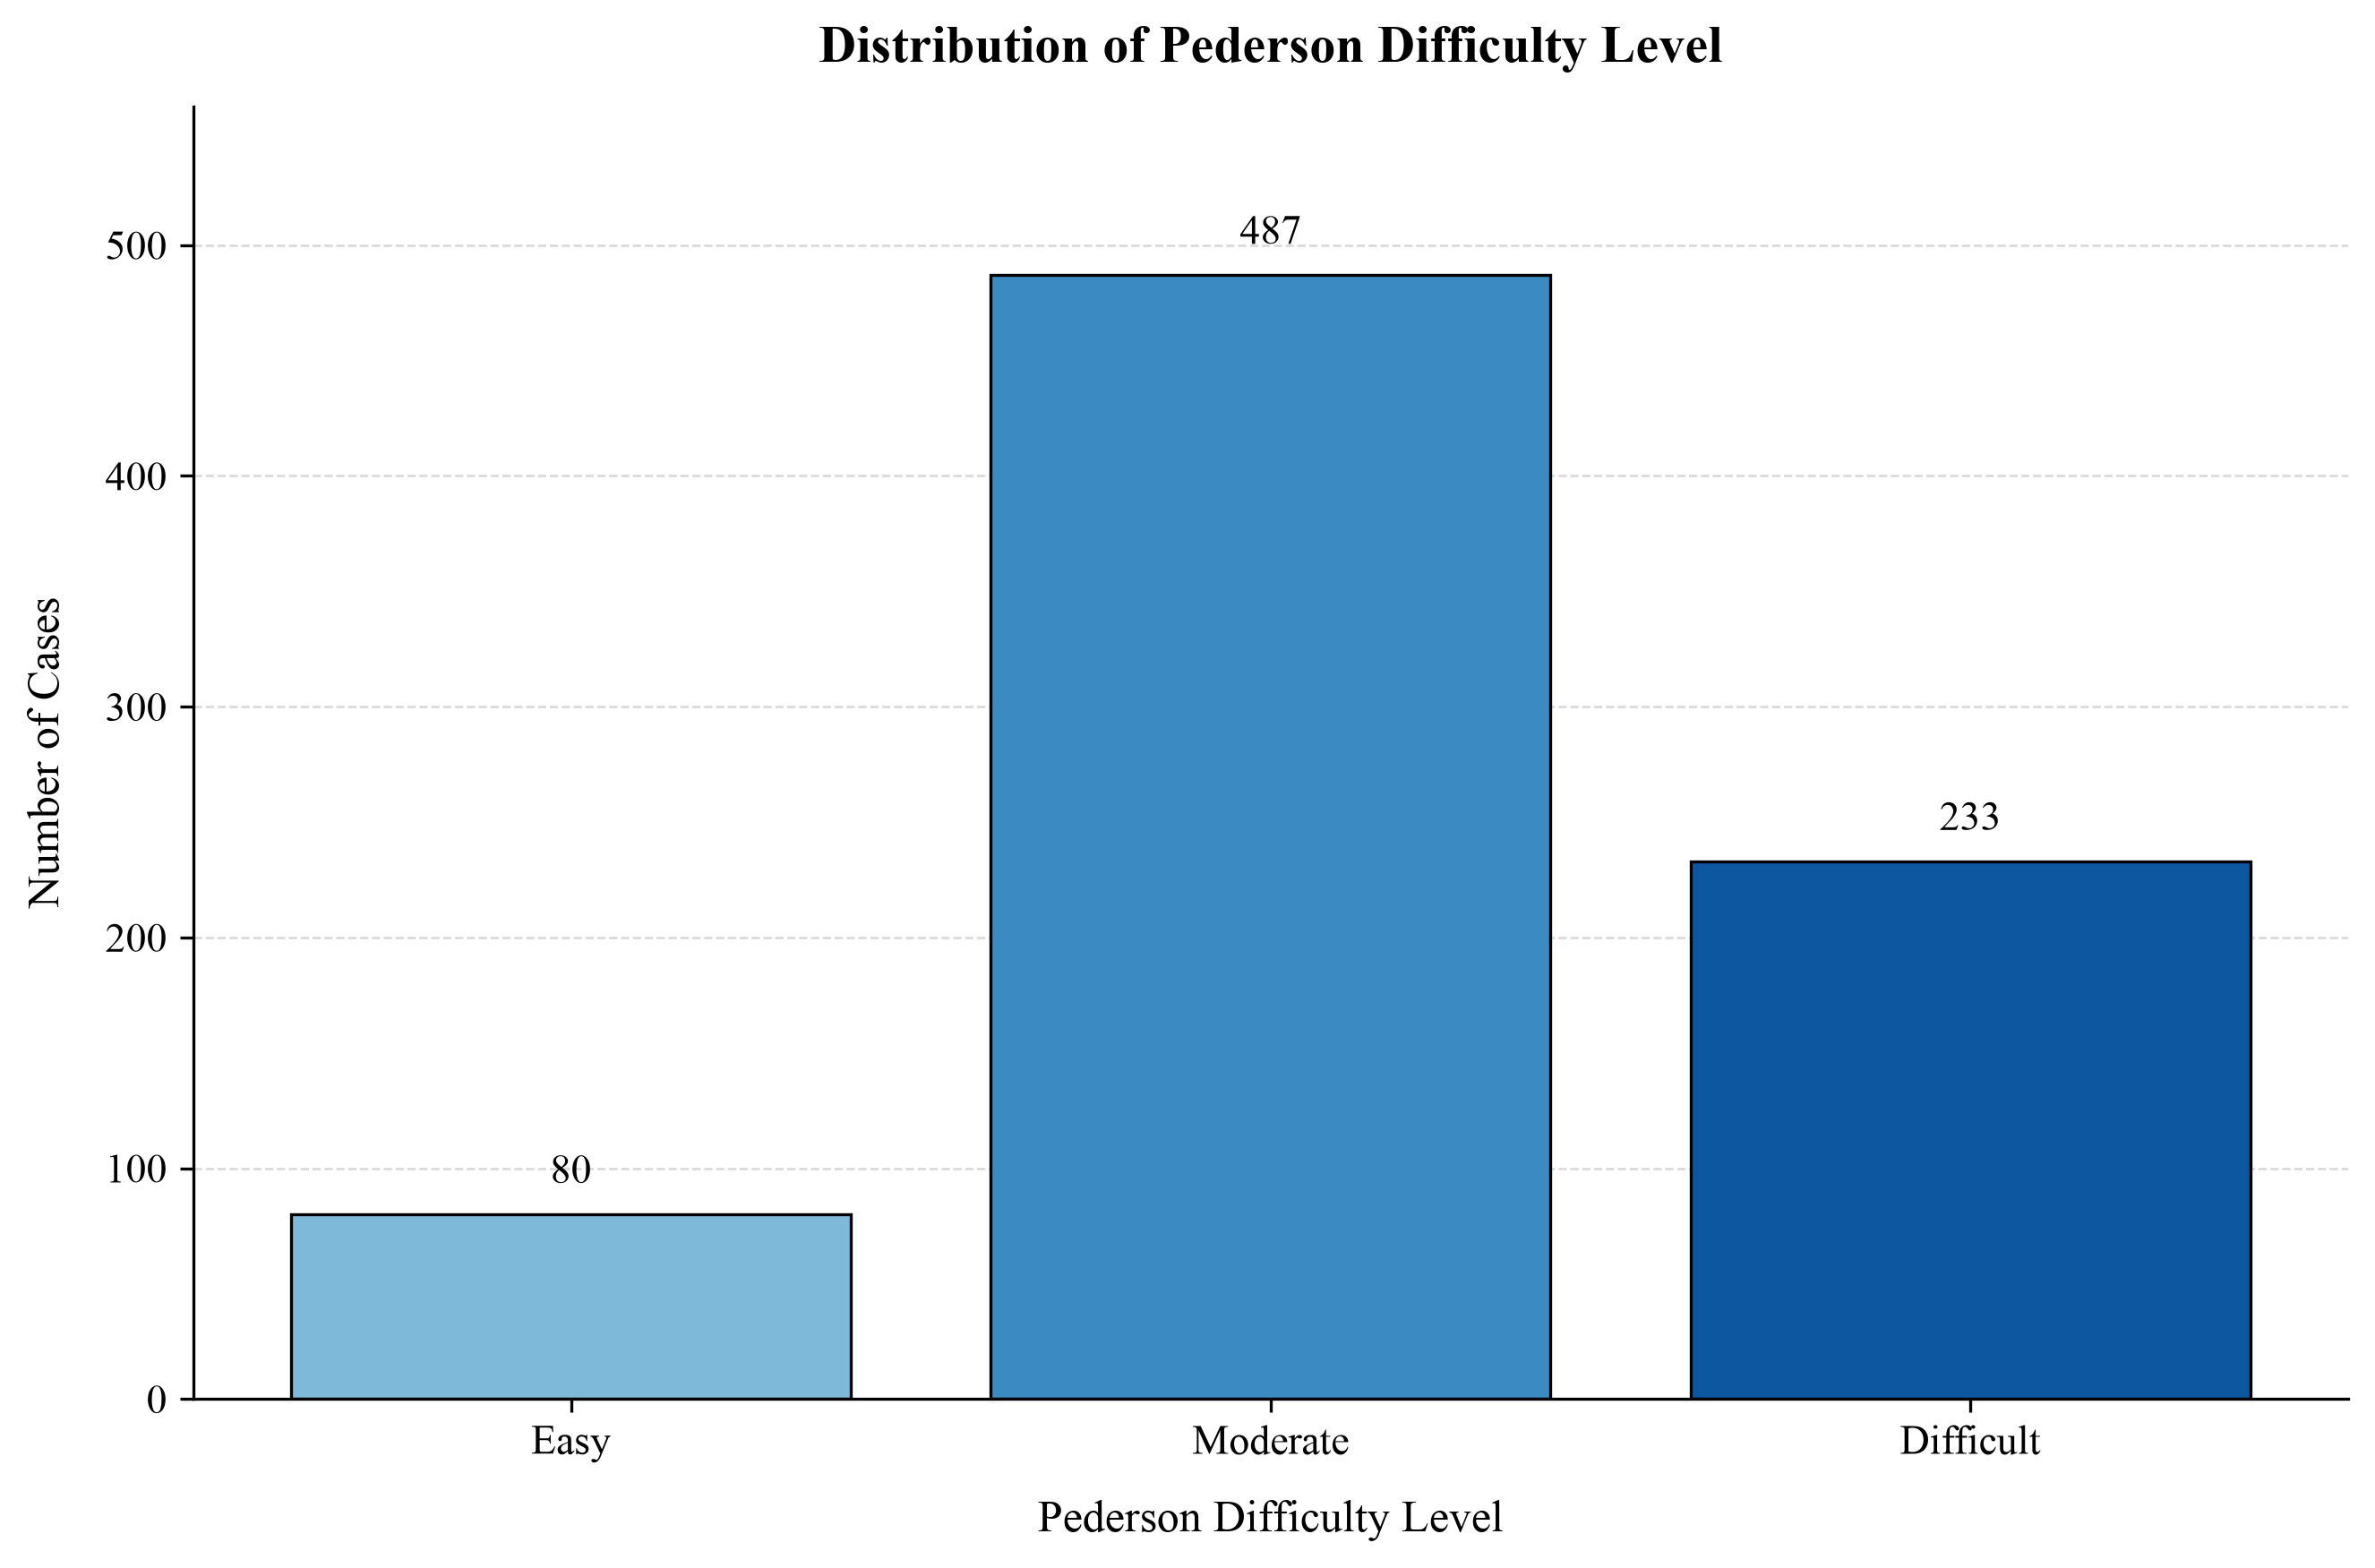

Saved: ../clinical_statistics_outputs/figures/pederson_difficulty_bar_chart.png


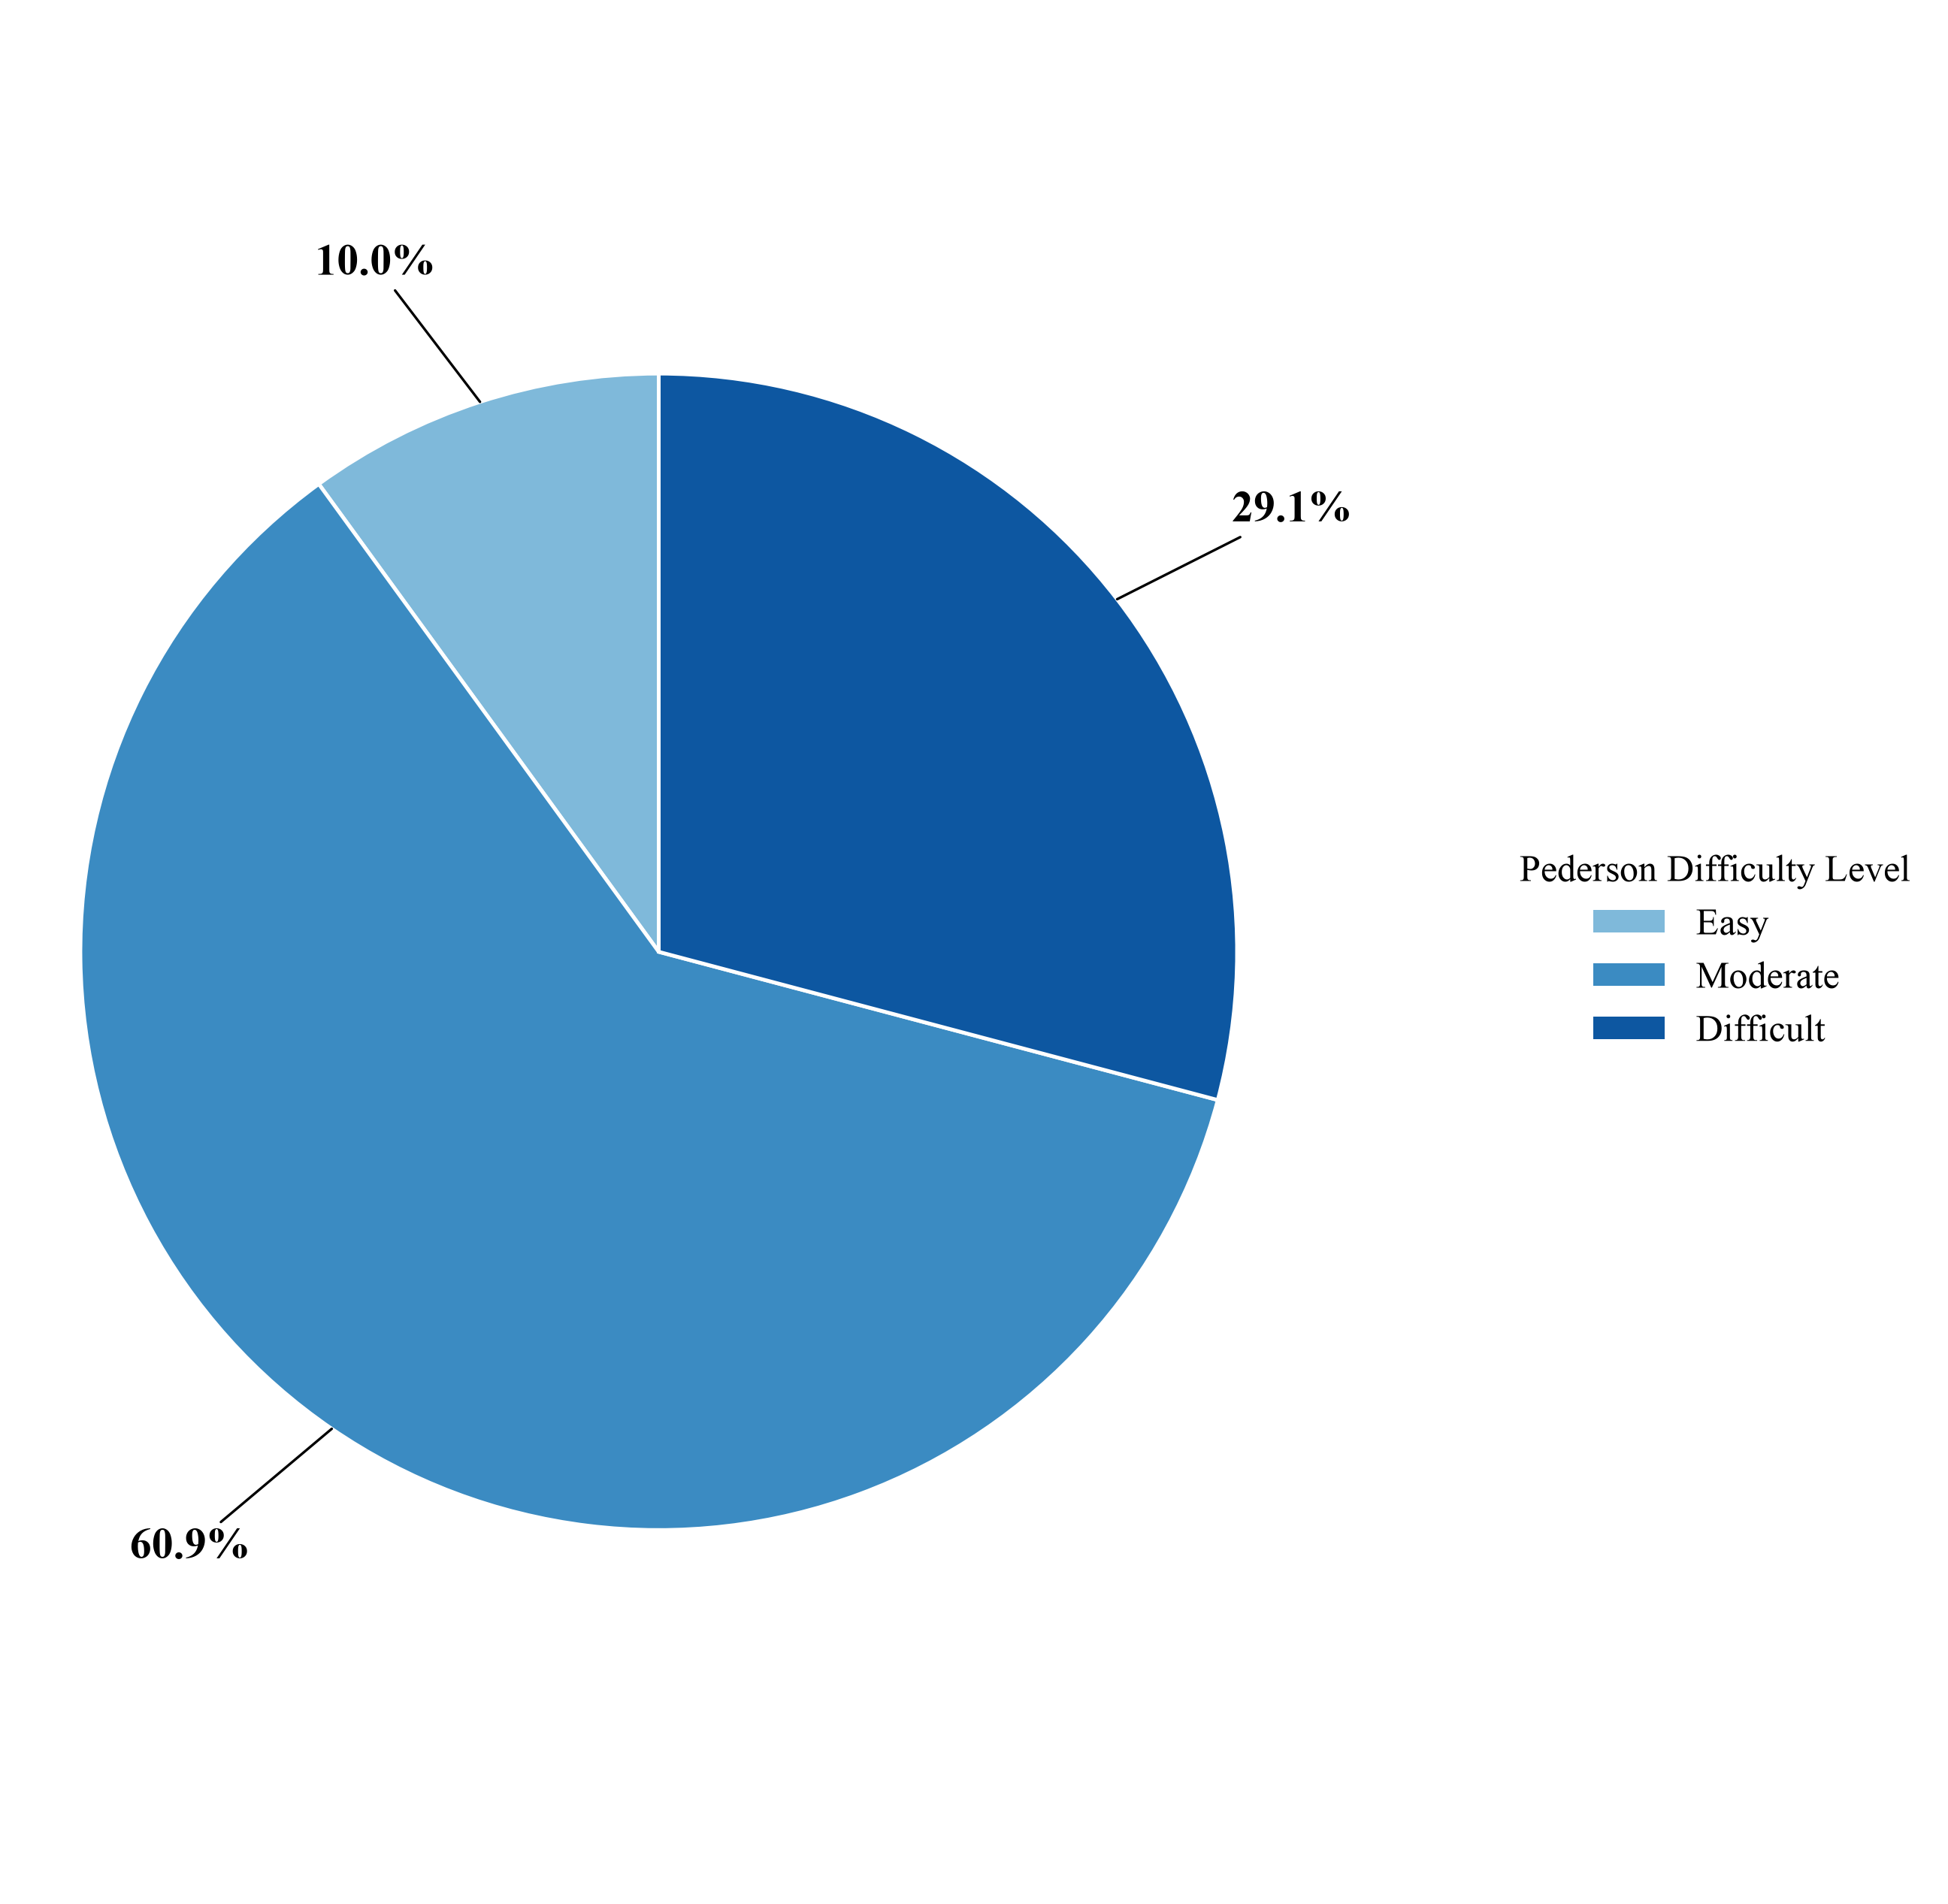

Saved: ../clinical_statistics_outputs/figures/pederson_difficulty_pie_chart.png


In [17]:
# ============================================================
# 9. Pederson difficulty groups
# ============================================================

def pederson_difficulty(score):
    """
    Convert Pederson score into difficulty groups.
    Common grouping:
    3-4: Easy
    5-6: Moderate
    7-10: Difficult
    """
    if pd.isna(score):
        return np.nan
    elif score <= 4:
        return "Easy"
    elif score <= 6:
        return "Moderate"
    else:
        return "Difficult"

df_clinical["pederson_difficulty"] = df_clinical["pederson"].apply(pederson_difficulty)

difficulty_order = ["Easy", "Moderate", "Difficult"]

difficulty_table = save_frequency_table(
    df_clinical,
    "pederson_difficulty",
    "Pederson Difficulty Level",
    order=difficulty_order
)

plot_bar(
    difficulty_table["Count"],
    "pederson_difficulty",
    "Pederson Difficulty Level"
)

plot_pie(
    difficulty_table["Count"],
    "pederson_difficulty",
    "Pederson Difficulty Level"
)

In [18]:
# ============================================================
# 10. Cross-tabulations
# ============================================================

cross_tab_pairs = [
    ("pell_gregory", "winter_angulation"),
    ("pell_gregory", "pederson_difficulty"),
    ("winter_angulation", "pederson_difficulty"),
    ("side", "pell_gregory"),
    ("side", "winter_angulation"),
    ("side", "pederson_difficulty")
]

for col1, col2 in cross_tab_pairs:
    crosstab = pd.crosstab(df_clinical[col1], df_clinical[col2])
    crosstab_percent = pd.crosstab(
        df_clinical[col1],
        df_clinical[col2],
        normalize="index"
    ) * 100

    print(f"\nCross-tabulation: {col1} vs {col2}")
    print(crosstab)

    crosstab.to_csv(
        os.path.join(tables_folder, f"crosstab_{col1}_vs_{col2}.csv")
    )

    crosstab_percent.round(2).to_csv(
        os.path.join(tables_folder, f"crosstab_percent_{col1}_vs_{col2}.csv")
    )


# ============================================================
# 11. Chi-square tests for categorical relationships
# ============================================================

chi_square_pairs = [
    ("pell_gregory", "winter_angulation"),
    ("pell_gregory", "pederson_difficulty"),
    ("winter_angulation", "pederson_difficulty"),
    ("side", "pell_gregory"),
    ("side", "winter_angulation"),
    ("side", "pederson_difficulty")
]

chi_square_results = []

for col1, col2 in chi_square_pairs:
    data_for_test = df_clinical[[col1, col2]].dropna()

    if data_for_test[col1].nunique() > 1 and data_for_test[col2].nunique() > 1:
        table, result = chi_square_test(data_for_test, col1, col2)

        chi_square_results.append({
            "Variable 1": col1,
            "Variable 2": col2,
            "Chi-square": result.loc[0, "Chi-square"],
            "p-value": result.loc[0, "p-value"],
            "Degrees of freedom": result.loc[0, "Degrees of freedom"]
        })

        print(f"\nChi-square test: {col1} vs {col2}")
        print(result)

    else:
        print(f"\nChi-square test skipped for {col1} vs {col2}: not enough categories.")

chi_square_results_df = pd.DataFrame(chi_square_results)

chi_square_results_df.to_csv(
    os.path.join(tables_folder, "chi_square_test_results.csv"),
    index=False
)

print("\nSummary of Chi-square Test Results")
print("----------------------------------")
print(chi_square_results_df)



Cross-tabulation: pell_gregory vs winter_angulation
winter_angulation  Distoangular  Horizontal  Mesioangular  Vertical
pell_gregory                                                       
1A                            0           5            18        42
1B                            0           3            16         1
1C                            0           2             7         0
2A                           31          47            41       113
2B                           17          69           127        46
2C                            0          10            36         3
3A                            0          10             4         1
3B                            0          29            25         4
3C                            1          28            60         4

Cross-tabulation: pell_gregory vs pederson_difficulty
pederson_difficulty  Difficult  Easy  Moderate
pell_gregory                                  
1A                           0    23        42
1B 

In [19]:

# ============================================================
# 12. Pederson score by Pell-Gregory and Winter angulation
# ============================================================

grouped_pederson_pell = df_clinical.groupby("pell_gregory")["pederson"].agg(
    ["count", "mean", "std", "median", "min", "max"]
).reindex(pell_order)

grouped_pederson_winter = df_clinical.groupby("winter_angulation")["pederson"].agg(
    ["count", "mean", "std", "median", "min", "max"]
)

grouped_pederson_side = df_clinical.groupby("side")["pederson"].agg(
    ["count", "mean", "std", "median", "min", "max"]
).reindex(side_order)

print("\nPederson Score by Pell-Gregory Class")
print("------------------------------------")
print(grouped_pederson_pell)

print("\nPederson Score by Winter Angulation")
print("-----------------------------------")
print(grouped_pederson_winter)

print("\nPederson Score by Side")
print("----------------------")
print(grouped_pederson_side)

grouped_pederson_pell.to_csv(
    os.path.join(tables_folder, "pederson_by_pell_gregory.csv")
)

grouped_pederson_winter.to_csv(
    os.path.join(tables_folder, "pederson_by_winter_angulation.csv")
)

grouped_pederson_side.to_csv(
    os.path.join(tables_folder, "pederson_by_side.csv")
)



Pederson Score by Pell-Gregory Class
------------------------------------
              count      mean       std  median  min  max
pell_gregory                                             
1A               65  4.415385  0.950202     5.0    3    6
1B               20  4.150000  0.587143     4.0    3    6
1C                9  5.222222  0.440959     5.0    5    6
2A              232  5.586207  0.926465     6.0    4    7
2B              259  5.799228  0.947375     5.0    5    8
2C               49  6.326531  0.591177     6.0    6    8
3A               15  5.866667  0.743223     6.0    5    8
3B               58  6.655172  0.608470     7.0    6    8
3C               93  7.419355  0.631124     7.0    7   10

Pederson Score by Winter Angulation
-----------------------------------
                   count      mean       std  median  min  max
winter_angulation                                             
Distoangular          49  7.408163  0.609589     7.0    7   10
Horizontal           203 

<Figure size 3000x1800 with 0 Axes>

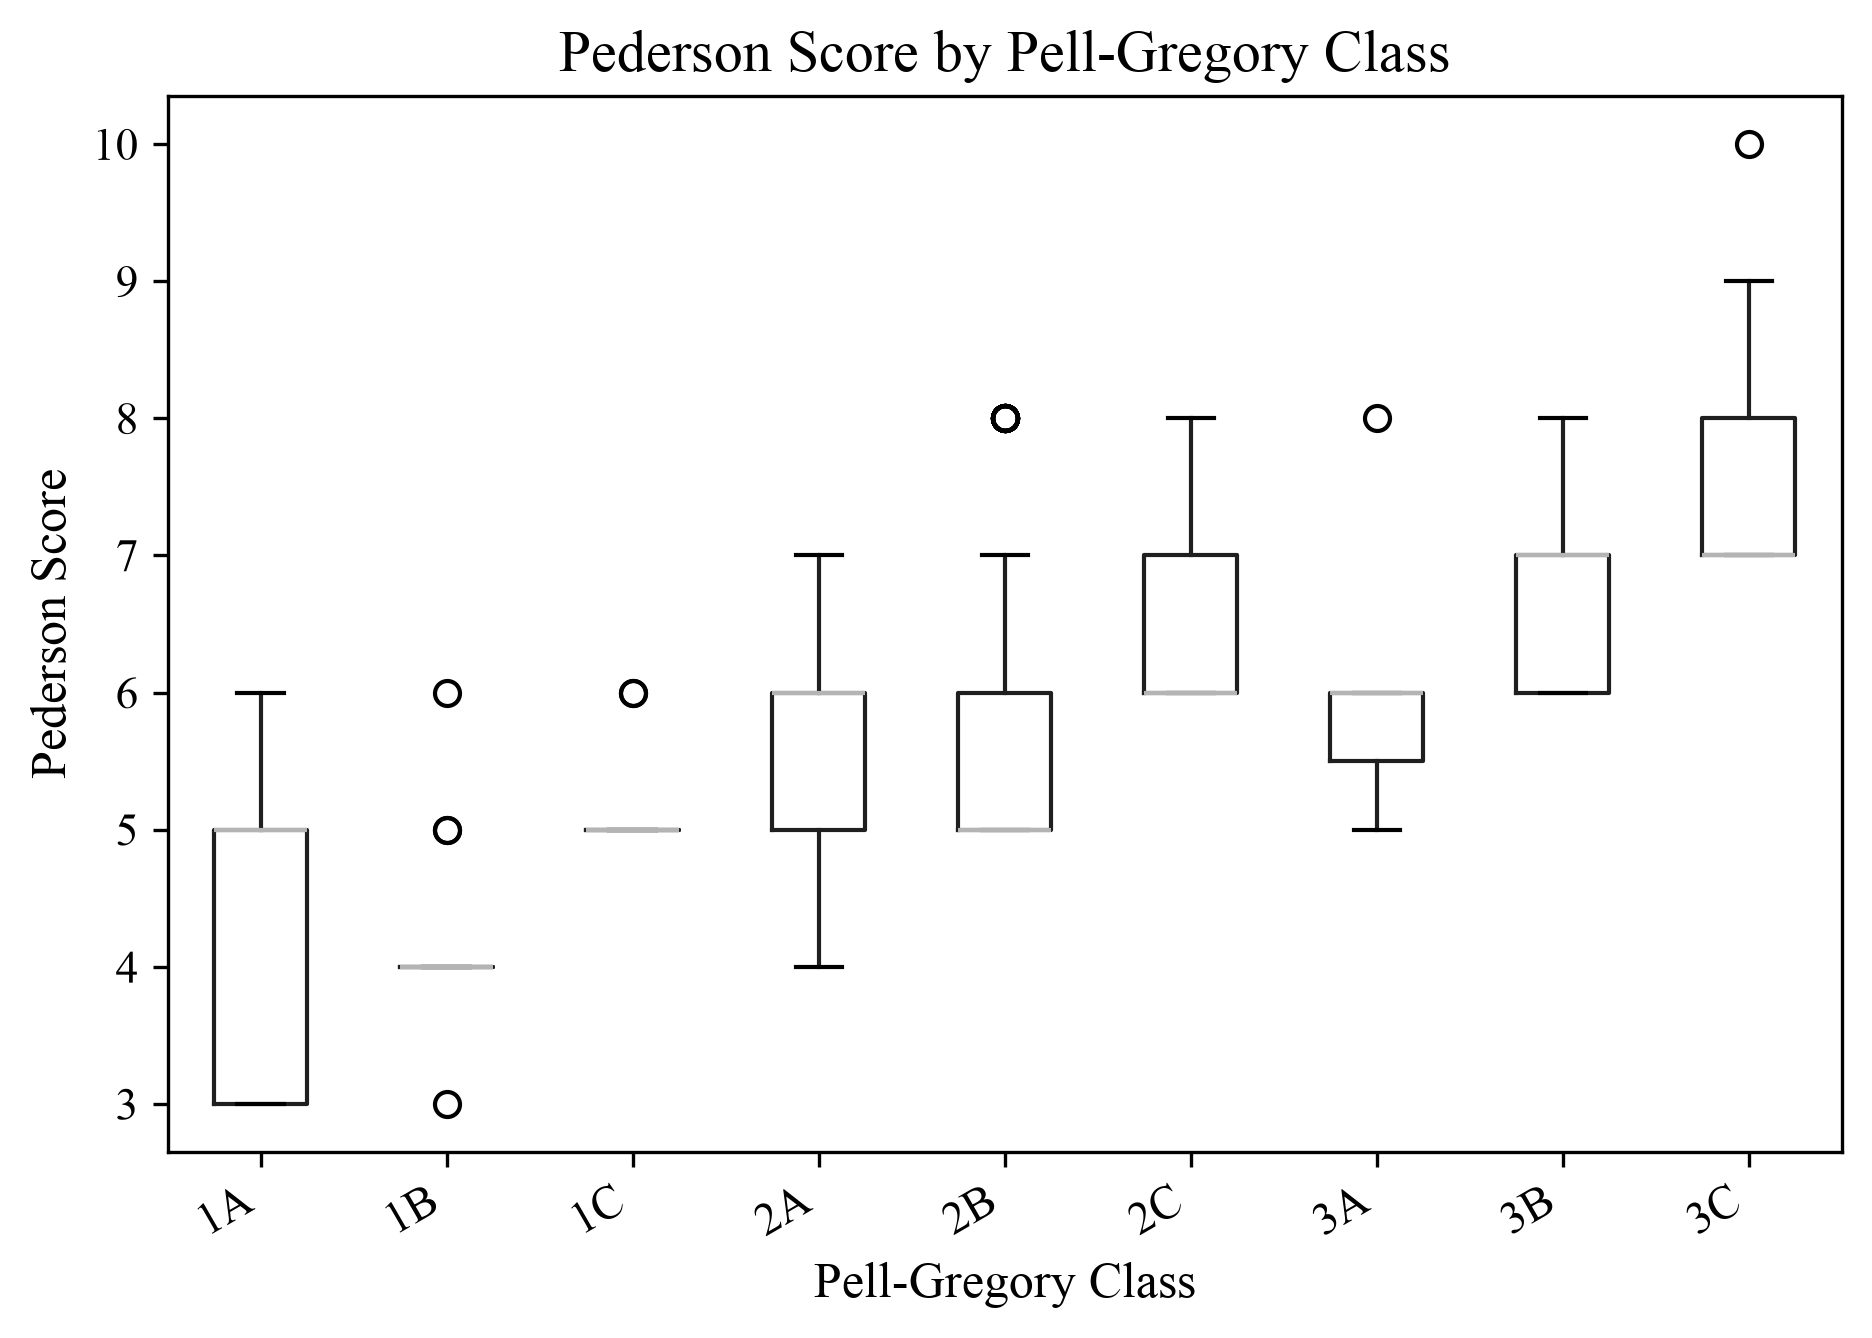

<Figure size 3000x1800 with 0 Axes>

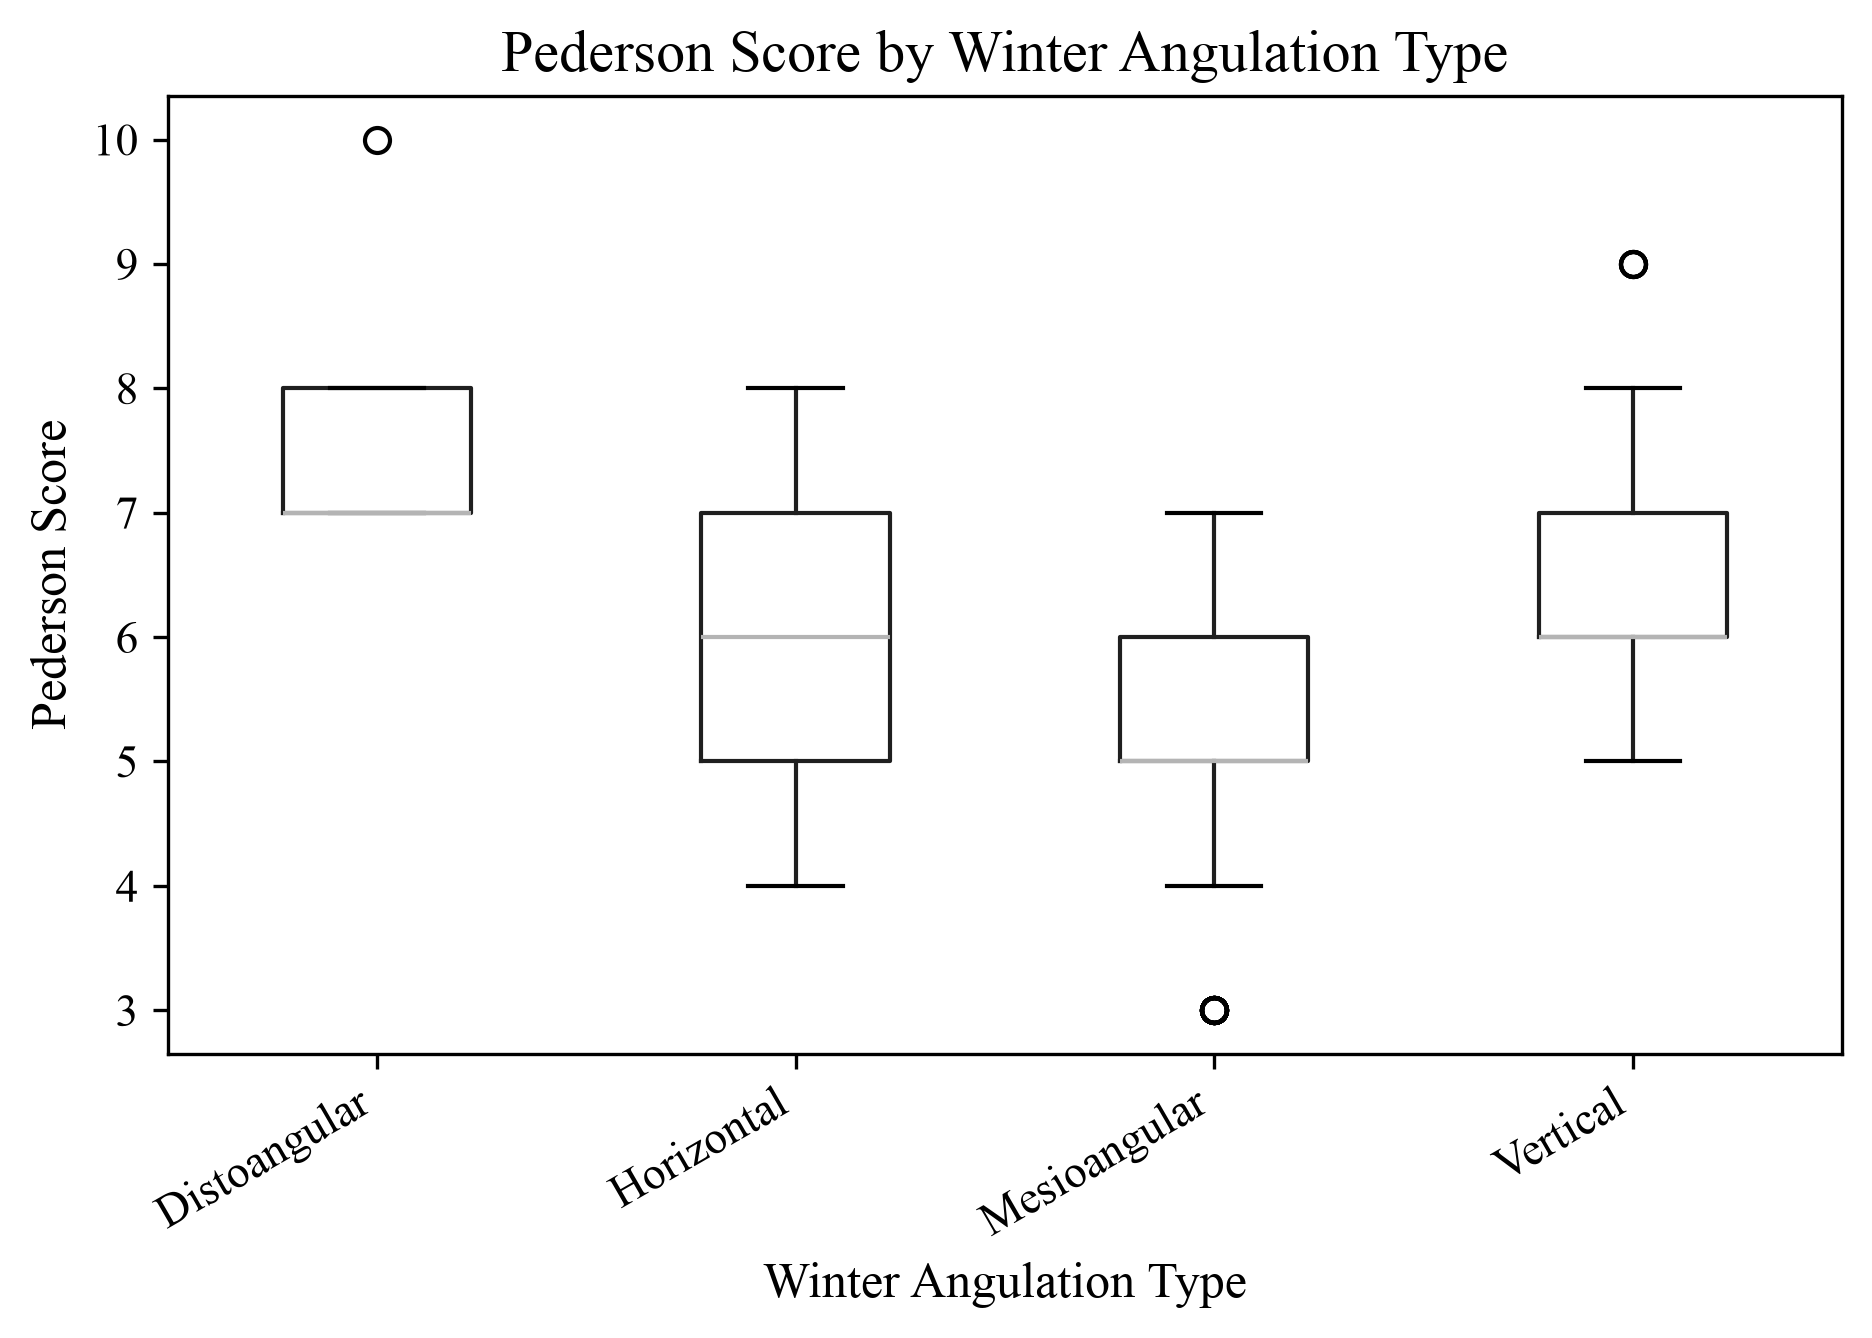

<Figure size 2100x1500 with 0 Axes>

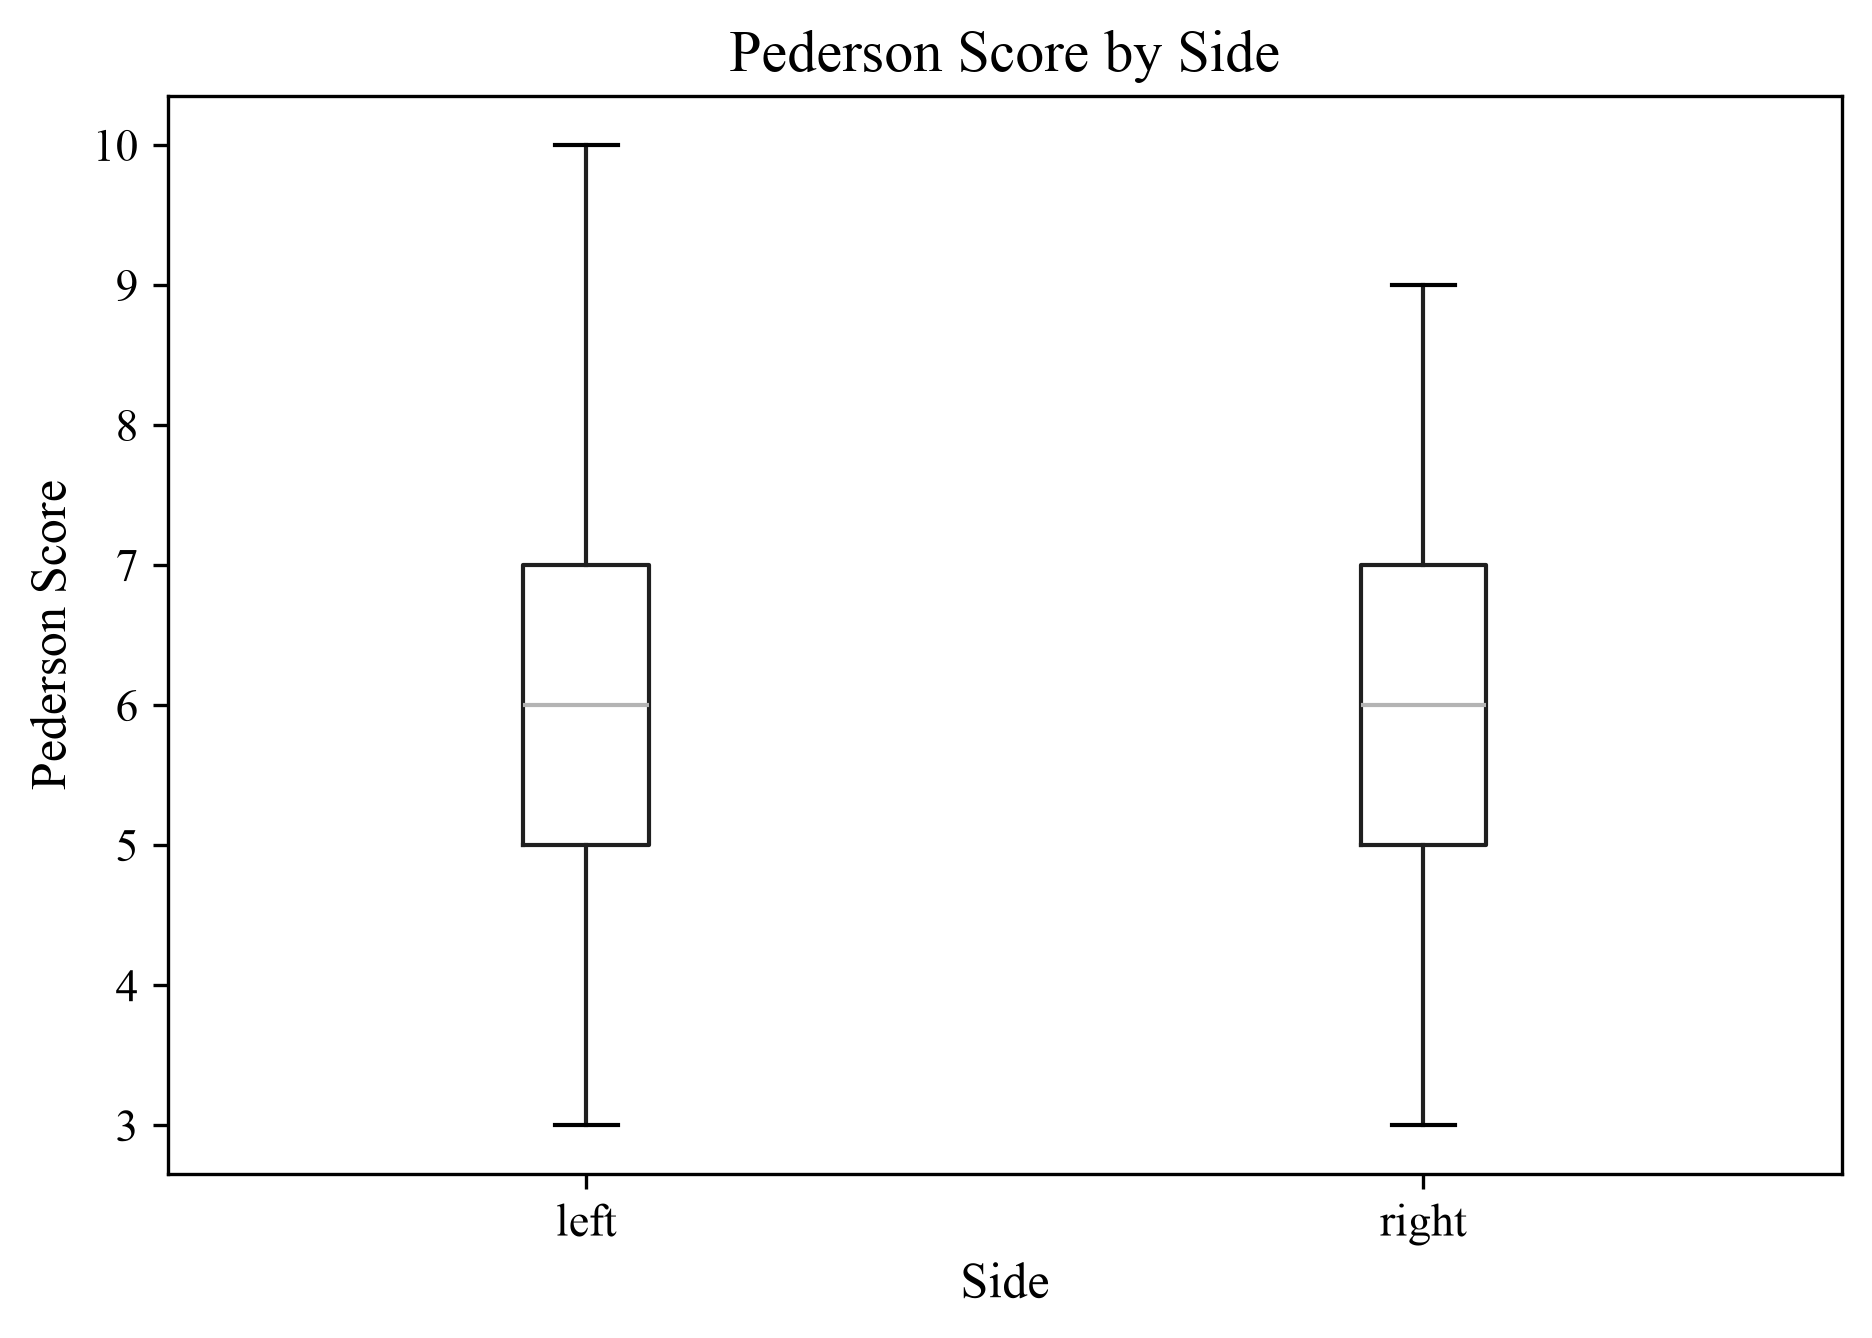

In [20]:
# ============================================================
# 13. Boxplots for Pederson score
# ============================================================

# Pederson score by Pell-Gregory
plt.figure(figsize=(10, 6))
df_clinical.boxplot(column="pederson", by="pell_gregory", grid=False)
plt.title("Pederson Score by Pell-Gregory Class")
plt.suptitle("")
plt.xlabel("Pell-Gregory Class")
plt.ylabel("Pederson Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

path = os.path.join(figures_folder, "boxplot_pederson_by_pell_gregory.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Pederson score by Winter angulation
plt.figure(figsize=(10, 6))
df_clinical.boxplot(column="pederson", by="winter_angulation", grid=False)
plt.title("Pederson Score by Winter Angulation Type")
plt.suptitle("")
plt.xlabel("Winter Angulation Type")
plt.ylabel("Pederson Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

path = os.path.join(figures_folder, "boxplot_pederson_by_winter_angulation.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Pederson score by side
plt.figure(figsize=(7, 5))
df_clinical.boxplot(column="pederson", by="side", grid=False)
plt.title("Pederson Score by Side")
plt.suptitle("")
plt.xlabel("Side")
plt.ylabel("Pederson Score")
plt.xticks(rotation=0)
plt.tight_layout()

path = os.path.join(figures_folder, "boxplot_pederson_by_side.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [21]:
# ============================================================
# 14. Non-parametric tests for Pederson score
# ============================================================

# Kruskal-Wallis test: Pederson score across Pell-Gregory classes
pell_groups = [
    group["pederson"].dropna().values
    for _, group in df_clinical.groupby("pell_gregory")
    if len(group["pederson"].dropna()) > 0
]

if len(pell_groups) > 1:
    stat, p = kruskal(*pell_groups)
    print("\nKruskal-Wallis Test: Pederson Score by Pell-Gregory")
    print("Statistic:", stat)
    print("p-value:", p)

# Kruskal-Wallis test: Pederson score across Winter angulation types
winter_groups = [
    group["pederson"].dropna().values
    for _, group in df_clinical.groupby("winter_angulation")
    if len(group["pederson"].dropna()) > 0
]

if len(winter_groups) > 1:
    stat, p = kruskal(*winter_groups)
    print("\nKruskal-Wallis Test: Pederson Score by Winter Angulation")
    print("Statistic:", stat)
    print("p-value:", p)

# Mann-Whitney U test: Pederson score between left and right sides
left_scores = df_clinical.loc[df_clinical["side"] == "left", "pederson"].dropna()
right_scores = df_clinical.loc[df_clinical["side"] == "right", "pederson"].dropna()

if len(left_scores) > 0 and len(right_scores) > 0:
    stat, p = mannwhitneyu(left_scores, right_scores, alternative="two-sided")
    print("\nMann-Whitney U Test: Pederson Score by Side")
    print("Statistic:", stat)
    print("p-value:", p)


Kruskal-Wallis Test: Pederson Score by Pell-Gregory
Statistic: 355.26446692765114
p-value: 6.808797438243859e-72

Kruskal-Wallis Test: Pederson Score by Winter Angulation
Statistic: 196.61751477441294
p-value: 2.2698257916921332e-42

Mann-Whitney U Test: Pederson Score by Side
Statistic: 85880.5
p-value: 0.06232957163791522


In [22]:
# ============================================================
# 15. Save cleaned clinical dataset
# ============================================================

cleaned_path = os.path.join(output_folder, "cleaned_clinical_dataset.xlsx")
df_clinical.to_excel(cleaned_path, index=False)

print("\nAnalysis completed.")
print(f"Cleaned dataset saved to: {cleaned_path}")
print(f"Figures saved to: {figures_folder}")
print(f"Tables saved to: {tables_folder}")


Analysis completed.
Cleaned dataset saved to: ../clinical_statistics_outputs/cleaned_clinical_dataset.xlsx
Figures saved to: ../clinical_statistics_outputs/figures
Tables saved to: ../clinical_statistics_outputs/tables


In [ ]:
# Column info
print(df.info())

In [ ]:
# Null value check
print(df.isnull().sum())

In [ ]:
# Basic statistics
print(df.describe())

In [ ]:
# Pell-Gregory distribution
print(df["pell_gregory"].value_counts())

In [ ]:
#for value in df["pell_gregory"].unique():
#    print(repr(value))

In [ ]:
# Pederson distribution
print(df["pederson"].value_counts())

In [ ]:
# Winter angulation distribution
print(df["winter_angulation"].value_counts())


In [ ]:
print(df["pell_gregory"].value_counts(normalize=True) * 100)

In [ ]:
print(df["winter_angulation"].value_counts(normalize=True) * 100)

In [ ]:
ct = pd.crosstab(df["gender_eng"], df["pell_gregory"])
print(ct)

ct_percent = pd.crosstab(
    df["gender_eng"],
    df["pell_gregory"],
    normalize="index"
) * 100

print(ct_percent)

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["gender_eng"], df["pell_gregory"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

In [ ]:
result = df.groupby("pell_gregory")["pederson"].agg(["count", "mean", "std", "min", "max"])

print(result)

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column="pederson", by="pell_gregory")

plt.title("Pell-Gregory Sınıfına Göre Pederson Skoru")
plt.suptitle("")
plt.xlabel("Pell-Gregory")
plt.ylabel("Pederson Skoru")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

pell_counts = df["pell_gregory"].value_counts()

plt.figure(figsize=(8, 5))
pell_counts.plot(kind="bar")

plt.title("Pell-Gregory Sınıflarının Dağılımı")
plt.xlabel("Pell-Gregory Sınıfı")
plt.ylabel("Hasta / Görüntü Sayısı")
plt.xticks(rotation=0)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

order = ["1A", "1B", "1C", "2A", "2B", "2C", "3A", "3B", "3C"]

pell_counts = df["pell_gregory"].value_counts().reindex(order, fill_value=0)

plt.figure(figsize=(8, 5))
ax = pell_counts.plot(kind="bar")

plt.title("Pell-Gregory Sınıflarının Dağılımı")
plt.xlabel("Pell-Gregory Sınıfı")
plt.ylabel("Hasta / Görüntü Sayısı")
plt.xticks(rotation=0)

for i, value in enumerate(pell_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

order = ["1A", "1B", "1C", "2A", "2B", "2C", "3A", "3B", "3C"]

pell_percent = (
    df["pell_gregory"]
    .value_counts(normalize=True)
    .reindex(order, fill_value=0) * 100
)

plt.figure(figsize=(8, 5))
ax = pell_percent.plot(kind="bar")

plt.title("Pell-Gregory Sınıflarının Yüzdelik Dağılımı")
plt.xlabel("Pell-Gregory Sınıfı")
plt.ylabel("Yüzde (%)")
plt.xticks(rotation=0)

for i, value in enumerate(pell_percent):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

# PART 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/My Drive/Dentistry"

In [ ]:
# Excel dosyasını oku
df = pd.read_excel("/content/drive/My Drive/Dentistry/hasta_listesi.xlsx")
print(df.head())
print(df.info())

In [ ]:
print("Number of records:", len(df))

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic age statistics:")
print(df["age"].describe())

###Pell Gregory

In [ ]:
pell_order = ["1A", "1B", "1C", "2A", "2B", "2C", "3A", "3B", "3C"]

pell_counts = df["pell_gregory"].value_counts().reindex(pell_order, fill_value=0)

plt.figure(figsize=(8, 5))
ax = pell_counts.plot(kind="bar")

plt.title("Distribution of Pell-Gregory Classes")
plt.xlabel("Pell-Gregory Class")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)

for i, value in enumerate(pell_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
pell_counts_nonzero = pell_counts[pell_counts > 0]

plt.figure(figsize=(7, 7))
plt.pie(
    pell_counts_nonzero,
    labels=pell_counts_nonzero.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Pell-Gregory Classes")
plt.tight_layout()
plt.show()

### Pederson

In [ ]:
pederson_counts = df["pederson"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = pederson_counts.plot(kind="bar")

plt.title("Distribution of Pederson Scores")
plt.xlabel("Pederson Score")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)

for i, value in enumerate(pederson_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# Check the current data type of the 'pederson' column
#print("Original 'pederson' column dtype:", df['pederson'].dtype)

# Convert the 'pederson' column to nullable integer type (Int64)
# This handles potential NaN values by representing them as <NA>
df['pederson'] = df['pederson'].astype(pd.Int64Dtype())

# Verify the new data type
print("New 'pederson' column dtype:", df['pederson'].dtype)

# Recalculate pederson_counts with the updated column
pederson_counts = df["pederson"].value_counts().sort_index()

# Plotting code as provided by the user
plt.figure(figsize=(8, 5))
ax = pederson_counts.plot(kind="bar")

plt.title("Distribution of Pederson Scores")
plt.xlabel("Pederson Score")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)

# Manually set x-tick labels to display as integers
# The index of pederson_counts will now be Int64.
ax.set_xticklabels(pederson_counts.index.astype(str))

for i, value in enumerate(pederson_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(
    pederson_counts,
    labels=pederson_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Pederson Scores")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))  # Increased figure size for better label spacing

# Custom autopct function to hide very small percentages (e.g., less than 1%)
def my_autopct(pct):
    return ('%1.1f%%' % pct) if pct > 1.0 else ''

wedges, texts, autotexts = plt.pie(
    pederson_counts,
    autopct=my_autopct,  # Use the custom autopct function
    startangle=90,
    pctdistance=0.85,  # Adjust distance of percentages from the center
    wedgeprops=dict(width=0.5, edgecolor='w')  # Create a donut chart effect
)

plt.title("Percentage Distribution of Pederson Scores")

# Create a legend for the categories (Pederson Scores) to avoid labels blending on the pie itself
plt.legend(wedges, pederson_counts.index.astype(str),
           title="Pederson Score",
           loc="center left",  # Position the legend
           bbox_to_anchor=(1, 0, 0.5, 1))  # Move the legend outside the plot area

plt.tight_layout()  # Adjust layout to prevent elements from overlapping
plt.show()

In [ ]:
winter_counts = df["winter_angulation"].value_counts()

plt.figure(figsize=(8, 5))
ax = winter_counts.plot(kind="bar")

plt.title("Distribution of Winter Angulation Types")
plt.xlabel("Winter Angulation Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=30, ha="right")

for i, value in enumerate(winter_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(
    winter_counts,
    labels=winter_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Winter Angulation Types")
plt.tight_layout()
plt.show()

In [ ]:
gender_counts = df["gender_eng"].value_counts()

plt.figure(figsize=(6, 5))
ax = gender_counts.plot(kind="bar")

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)

for i, value in enumerate(gender_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Gender")
plt.tight_layout()
plt.show()

In [ ]:
bins = [0, 20, 30, 40, 50, 100]
labels = ["≤20", "21–30", "31–40", "41–50", "51+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

age_group_counts = df["age_group"].value_counts().reindex(labels, fill_value=0)

print(age_group_counts)

In [ ]:
plt.figure(figsize=(8, 5))
ax = age_group_counts.plot(kind="bar")

plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)

for i, value in enumerate(age_group_counts):
    ax.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

age_group_counts_nonzero = age_group_counts[age_group_counts > 0]

plt.figure(figsize=(9, 9)) # Increased figure size for better label spacing

# Custom autopct function to hide very small percentages (e.g., less than 1%)
def my_autopct(pct):
    return ('%1.1f%%' % pct) if pct > 1.0 else ''

wedges, texts, autotexts = plt.pie(
    age_group_counts_nonzero,
    autopct=my_autopct, # Use the custom autopct function
    startangle=90,
    pctdistance=0.85, # Adjust distance of percentages from the center
    wedgeprops=dict(width=0.5, edgecolor='w') # Create a donut chart effect
)

plt.title("Percentage Distribution of Age Groups")

# Create a legend for the categories (Age Groups) to avoid labels blending on the pie itself
plt.legend(wedges, age_group_counts_nonzero.index.astype(str),
           title="Age Group",
           loc="center left", # Position the legend
           bbox_to_anchor=(1, 0, 0.5, 1)) # Move the legend outside the plot area

plt.tight_layout() # Adjust layout to prevent elements from overlapping
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# If age_group has not been created yet, create it first
bins = [0, 20, 30, 40, 50, 100]
labels = ["≤20", "21–30", "31–40", "41–50", "51+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

# Custom autopct function to hide very small percentages
def my_autopct(pct):
    return ('%1.1f%%' % pct) if pct > 1.0 else ''

# Optional order definitions for selected columns
pell_order = ["1A", "1B", "1C", "2A", "2B", "2C", "3A", "3B", "3C"]
age_order = ["≤20", "21–30", "31–40", "41–50", "51+"]
gender_order = ["female", "male"]

categorical_columns = {
    "pell_gregory": "Pell-Gregory Class",
    "pederson": "Pederson Score",
    "winter_angulation": "Winter Angulation Type",
    "gender_eng": "Gender",
    "age_group": "Age Group"
}

for column, label in categorical_columns.items():

    # Ordered counts for specific columns
    if column == "pell_gregory":
        counts = df[column].value_counts().reindex(pell_order, fill_value=0)
    elif column == "age_group":
        counts = df[column].value_counts().reindex(age_order, fill_value=0)
    elif column == "gender_eng":
        counts = df[column].value_counts().reindex(gender_order, fill_value=0)
    else:
        counts = df[column].value_counts().sort_index()

    # Remove zero-count categories for plotting if needed
    counts_nonzero = counts[counts > 0]

    # ---------------------------
    # Colored Bar Chart
    # ---------------------------
    plt.figure(figsize=(9, 6))

    bar_colors = plt.cm.Set3(np.linspace(0, 1, len(counts_nonzero)))
    ax = plt.bar(counts_nonzero.index.astype(str), counts_nonzero.values, color=bar_colors)

    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Number of Cases")
    plt.xticks(rotation=30, ha="right")

    # Add values on top of bars
    for i, value in enumerate(counts_nonzero.values):
        plt.text(i, value + 0.5, str(value), ha="center")

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # Donut Pie Chart
    # ---------------------------
    plt.figure(figsize=(9, 9))

    pie_colors = plt.cm.Pastel1(np.linspace(0, 1, len(counts_nonzero)))

    wedges, texts, autotexts = plt.pie(
        counts_nonzero,
        autopct=my_autopct,
        startangle=90,
        pctdistance=0.85,
        colors=pie_colors,
        wedgeprops=dict(width=0.5, edgecolor='w')
    )

    plt.title(f"Percentage Distribution of {label}")

    plt.legend(
        wedges,
        counts_nonzero.index.astype(str),
        title=label,
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1)
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output folder for figures
output_folder = "figures"
os.makedirs(output_folder, exist_ok=True)

# If age_group has not been created yet, create it first
bins = [0, 20, 30, 40, 50, 100]
labels = ["≤20", "21–30", "31–40", "41–50", "51+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

# Custom autopct function to hide very small percentages
def my_autopct(pct):
    return ('%1.1f%%' % pct) if pct > 1.0 else ''

# Optional order definitions for selected columns
pell_order = ["1A", "1B", "1C", "2A", "2B", "2C", "3A", "3B", "3C"]
age_order = ["≤20", "21–30", "31–40", "41–50", "51+"]
gender_order = ["female", "male"]

categorical_columns = {
    "pell_gregory": "Pell-Gregory Class",
    "pederson": "Pederson Score",
    "winter_angulation": "Winter Angulation Type",
    "gender_eng": "Gender",
    "age_group": "Age Group"
}

for column, label in categorical_columns.items():

    # Ordered counts for specific columns
    if column == "pell_gregory":
        counts = df[column].value_counts().reindex(pell_order, fill_value=0)
    elif column == "age_group":
        counts = df[column].value_counts().reindex(age_order, fill_value=0)
    elif column == "gender_eng":
        counts = df[column].value_counts().reindex(gender_order, fill_value=0)
    else:
        counts = df[column].value_counts().sort_index()

    # Remove zero-count categories for plotting
    counts_nonzero = counts[counts > 0]

    # Skip empty charts
    if counts_nonzero.empty:
        print(f"No data available for {column}. Skipping...")
        continue

    # ---------------------------
    # Colored Bar Chart
    # ---------------------------
    plt.figure(figsize=(9, 6))

    bar_colors = plt.cm.Set3(np.linspace(0, 1, len(counts_nonzero)))

    plt.bar(
        counts_nonzero.index.astype(str),
        counts_nonzero.values,
        color=bar_colors
    )

    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Number of Cases")
    plt.xticks(rotation=30, ha="right")

    # Add values on top of bars
    for i, value in enumerate(counts_nonzero.values):
        plt.text(i, value + 0.5, str(value), ha="center")

    plt.tight_layout()

    # Save bar chart
    bar_filename = f"{column}_bar_chart.png"
    bar_path = os.path.join(output_folder, bar_filename)
    plt.savefig(bar_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

    # ---------------------------
    # Donut Pie Chart
    # ---------------------------
    plt.figure(figsize=(9, 9))

    pie_colors = plt.cm.Pastel1(np.linspace(0, 1, len(counts_nonzero)))

    wedges, texts, autotexts = plt.pie(
        counts_nonzero,
        autopct=my_autopct,
        startangle=90,
        pctdistance=0.85,
        colors=pie_colors,
        wedgeprops=dict(width=0.5, edgecolor="w")
    )

    plt.title(f"Percentage Distribution of {label}")

    plt.legend(
        wedges,
        counts_nonzero.index.astype(str),
        title=label,
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1)
    )

    plt.tight_layout()

    # Save pie chart
    pie_filename = f"{column}_pie_chart.png"
    pie_path = os.path.join(output_folder, pie_filename)
    plt.savefig(pie_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

    print(f"Saved: {bar_path}")
    print(f"Saved: {pie_path}")